# Modelamiento avanzado - Telco Customer Churn

## 1. Modelos implementados y resultados obtenidos

### 1.1 Problema, continuidad y criterio de decisión

Se estudia la clasificación binaria de abandono de clientes de telecomunicaciones: **Churn=Yes es la clase positiva (1)** y permanencia es la clase negativa (0). El modelado continúa el ETL, EDA, preprocesamiento y modelado inicial previamente realizados. 

El objetivo es identificar clientes en riesgo: interesa un Recall elevado. Se utiliza **F1 positivo como único criterio de optimización**, porque combina Precision y Recall y penaliza las falsas alertas que una optimización aislada de Recall podría ignorar. ROC-AUC, Accuracy, Precision y Recall complementan la evaluación. No se dispone de una razón numérica de costes; no se afirma que F1 maximice rentabilidad. La referencia experimental es **Sin balanceo** dentro de cada familia, sin añadir clasificadores triviales.

La evidencia principal procede de validación cruzada anidada sobre 5.634 clientes de desarrollo, con 1.495 abandonos (26,54 %). Se conserva el test histórico de 1.409 clientes, ya expuesto durante la primera entrega: su uso posterior es suplementario y no equivale a una nueva validación externa independiente.

- **Configuración del entorno:** Antes de ejecutar el notebook, es **indispensable** usar un entorno virtual con python 3.12 que tenga instalado `requirements.txt`. Siga estos pasos para crear el entorno virtual:

> 1. Abrir *Anaconda PowerShell Prompt*

> 2. Ejecutar los siguientes comandos:
> ```bash
> conda create -n ml_project python=3.12 -y
> conda activate ml_project
> cd "RUTA_DE_LA_CARPETA_DEL_PROYECTO"
> python -m pip install -r requirements.txt

In [11]:
from pathlib import Path
from itertools import combinations
import json, hashlib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
from scipy.stats import friedmanchisquare, studentized_range, norm, skew

ROOT = Path.cwd()
ANALISIS = ROOT / 'resultados_modelado/analisis_final'
OFICIAL = ROOT / 'resultados_modelado/oficial/20260920T030103_517c8c6b7906_69c6c7'
SEMILLA_GLOBAL = 42
RECALCULAR_COSTOSO = False
MODO = 'resultados_guardados_y_derivaciones_ligeras'
assert ANALISIS.is_dir(), 'Ejecutar desde la carpeta que contiene los tres notebooks.'

def leer_tabla(nombre):
    """Lee CSV preservando exactamente scores y empates."""
    return pd.read_csv(ANALISIS / nombre, float_precision='round_trip')

def tabla(frame, decimales=4):
    """Presenta todas las filas sin modificar los valores de origen."""
    display(frame.style.hide(axis='index').format(precision=decimales, na_rep='No aplica')
            .format({c:'{:.3e}' for c in frame if c in ['p_raw','p_holm','p_exploratory']})
            .set_table_attributes('style="font-size:12px"'))

UNIDADES = leer_tabla('unidades.csv')
PRINCIPAL = UNIDADES[UNIDADES.replicate == 0].copy()
METRICAS = ['accuracy','precision_positive','recall_positive','f1_positive','roc_auc','brier','ece']
RESUMEN = PRINCIPAL.groupby(['experiment_id','model','balance','optimizer'])[METRICAS].agg(['mean','std'])
RESUMEN.columns = ['_'.join(c) for c in RESUMEN.columns]
RESUMEN = RESUMEN.reset_index().sort_values(['f1_positive_mean','experiment_id'],ascending=[False,True])
MODELOS = ['knn','naive_bayes','logistic','decision_tree','random_forest','xgboost','svm']
NOMBRES = {'knn':'KNN','naive_bayes':'GaussianNB','logistic':'Logística','decision_tree':'Árbol','random_forest':'Random Forest','xgboost':'XGBoost','svm':'SVM'}
BALANCEOS = {'none':'Sin balanceo','smote':'SMOTE','adasyn':'ADASYN','balanced':'Ponderación'}
OPTIMIZADORES = {'grid':'Grid','random':'Random','bayesian_tpe':'TPE','genetic':'Genético'}
REPRESENTANTES = RESUMEN.drop_duplicates('model').set_index('model').loc[MODELOS].reset_index()
assert len(RESUMEN)==112 and len(UNIDADES)==1680
assert not UNIDADES.duplicated(['experiment_id','replicate','outer_fold']).any()
assert UNIDADES.groupby(['experiment_id','replicate']).size().eq(5).all()
assert UNIDADES.evaluations.eq(24).all()
np.testing.assert_allclose(RESUMEN.set_index('experiment_id').sort_index().select_dtypes('number'),
    leer_tabla('resumen_112.csv').set_index('experiment_id').sort_index().select_dtypes('number'),rtol=1e-12,atol=1e-14)

AssertionError: Ejecutar desde la carpeta que contiene los tres notebooks.

### 1.2 Universo experimental y reproducibilidad

Se mantuvo un diseño factorial de siete familias, cuatro balanceos y cuatro optimizadores. Las 112 configuraciones se evaluaron con los mismos folds. Se realizaron tres realizaciones algorítmicas; la principal se identifica como realización 0. Las otras dos permiten observar sensibilidad a semillas sin confundirlas con nuevas muestras independientes.

La semilla raíz fue 42. `SeedSequence` derivó semillas por función y coordenadas (realización, fold y candidato), separando particiones, modelo, remuestreo, optimizador y calibración. Las particiones externas e internas se mantuvieron comunes para emparejar comparaciones. El registro conserva las semillas efectivamente utilizadas, no solo la raíz.

In [ ]:
tabla(pd.DataFrame([{'Familias':UNIDADES.model.nunique(),'Balanceos':UNIDADES.balance.nunique(),'Optimizadores':UNIDADES.optimizer.nunique(),'Configuraciones':UNIDADES.experiment_id.nunique(),'Realizaciones':UNIDADES.replicate.nunique(),'Folds externos':UNIDADES.outer_fold.nunique(),'Unidades terminadas':len(UNIDADES),'Candidatos por búsqueda':int(UNIDADES.evaluations.min())}]))

Familias,Balanceos,Optimizadores,Configuraciones,Realizaciones,Folds externos,Unidades terminadas,Candidatos por búsqueda
7,4,4,112,3,5,1680,24


**Interpretación.** La cobertura corresponde a 112 × 3 × 5 = **1.680 unidades externas**, sin configuraciones omitidas. Cada búsqueda consumió 24 evaluaciones únicas. Las realizaciones no amplían el número de datasets ni convierten los folds solapados en observaciones independientes. Estos resultados son oficiales; los pilotos técnicos no se incorporan a las tablas.

### 1.3 Pipeline: transformaciones y prevención de fuga de información

Cada ajuste construyó un Pipeline nuevo con el orden:

**Datos originales → reglas deterministas → escalado/codificación → balanceo del entrenamiento → clasificador.**

Se recuperaron el CSV original y los índices históricos, no matrices previamente escaladas. `TotalCharges` se convirtió a numérico; los blancos con antigüedad cero se trataron con la regla histórica. Se unificaron categorías de ausencia de servicio y se calculó `AvgChargePerMonth`, con respaldo en `MonthlyCharges` cuando la antigüedad es cero. Son reglas deterministas, no estimaciones aprendidas usando validación.

`StandardScaler` se ajustó sobre tenure, MonthlyCharges, TotalCharges, SeniorCitizen y AvgChargePerMonth. `OneHotEncoder(drop='first', handle_unknown='ignore')` se ajustó sobre las variables categóricas del entrenamiento. La representación usada tiene 24 columnas. La imputación determinista no autoriza a calcular medias o escalas globales: los parámetros aprendidos se estiman únicamente en cada subconjunto de ajuste.

El balanceo se ubicó dentro de `imblearn.Pipeline`, después de transformar las variables. En validación y prueba solo se transforma y predice; nunca se remuestrean sus observaciones. SMOTE y ADASYN sobre one-hot pueden generar indicadores fraccionarios y utilizan distancias sobre esta representación. Esta limitación se conserva al interpretar sus resultados; no se sustituyó retrospectivamente el procedimiento por otro.

#### Familias y capacidad del modelo

KNN usa consulta exacta `brute` y distancias Minkowski; GaussianNB estima distribuciones gaussianas por clase y variable; Logística utiliza `liblinear` y regularización L1/L2; Decision Tree y Random Forest controlan capacidad mediante profundidad y tamaño mínimo de hoja; XGBoost utiliza histogramas en CPU y objetivo binario; SVM usa kernel RBF con `probability=False`.

Estas familias cubren vecinos, modelos probabilísticos, separación lineal regularizada, árboles, ensambles y separación no lineal. La evaluación aplica la misma métrica interna y los mismos folds. Ninguna familia se elimina por obtener un desempeño menor.

In [ ]:
tabla(pd.DataFrame([{'Estrategia':'Sin balanceo','Operación':'Conserva frecuencias del entrenamiento','Justificación':'Línea base dentro de cada familia'}, {'Estrategia':'SMOTE','Operación':'5 vecinos; sampling_strategy=1.0','Justificación':'Genera minoritarios interpolados solo en fit'}, {'Estrategia':'ADASYN','Operación':'5 vecinos; sampling_strategy=1.0','Justificación':'Concentra generación en zonas difíciles del entrenamiento'}, {'Estrategia':'Ponderación balanceada','Operación':'w_c=n/(2 n_c), calculado dentro de fit','Justificación':'Aumenta contribución de la clase menos frecuente'}]))

Estrategia,Operación,Justificación
Sin balanceo,Conserva frecuencias del entrenamiento,Línea base dentro de cada familia
SMOTE,5 vecinos; sampling_strategy=1.0,Genera minoritarios interpolados solo en fit
ADASYN,5 vecinos; sampling_strategy=1.0,Concentra generación en zonas difíciles del entrenamiento
Ponderación balanceada,"w_c=n/(2 n_c), calculado dentro de fit",Aumenta contribución de la clase menos frecuente


**Interpretación metodológica.** Las cuatro estrategias cambian el aprendizaje, no la prevalencia de evaluación. Logística, árboles, Random Forest y SVM usan pesos de clase nativos; GaussianNB y XGBoost reciben pesos por observación; KNN pondera explícitamente el voto de sus vecinos por clase. Esta última es una adaptación documentada, no una opción nativa `class_weight` de KNN. Los pesos se recalculan por entrenamiento y no se asume que sus scores queden calibrados.

### 1.4 Validación cruzada anidada y registro por unidad

Se emplearon **cinco folds externos estratificados y tres internos estratificados**. Para cada realización y fold externo:

1. Se reservó el fold externo sin utilizar sus etiquetas para elegir parámetros.
2. Cada candidato se evaluó sobre los tres folds internos. En cada uno se ajustaron de nuevo transformaciones, balanceo y clasificador exclusivamente en entrenamiento interno.
3. El optimizador recibió únicamente la media de F1 positivo interno.
4. Se eligió el candidato con mejor media interna y se reajustó el Pipeline sobre todo el entrenamiento externo.
5. Se guardaron etiquetas, scores y probabilidades del fold externo; estas predicciones sustentan el reporte principal.

El mismo evaluador interno se usó para los cuatro optimizadores. Un candidato repetido se recupera solo dentro de su búsqueda y no consume otra evaluación única. No se comparten ajustes entre optimizadores: hacerlo favorecería artificialmente su tiempo medido. Las particiones y estructuras administrativas sí pueden reutilizarse, porque no incorporan aprendizaje de validación.

Cada unidad tiene identificadores de configuración, realización y fold. Los checkpoints guardan parámetros, semillas, tiempos, métricas internas/externas separadas y hashes. Se publican como completos solo tras verificarse sus artefactos. Un bloqueo impide dos escritores simultáneos; recuperar una interrupción no elimina intentos anteriores.

In [ ]:
tabla(UNIDADES[['experiment_id','replicate','outer_fold','best_inner_f1','f1_positive','evaluations','model_seed','sampler_seed','optimizer_seed']].head(3))

experiment_id,replicate,outer_fold,best_inner_f1,f1_positive,evaluations,model_seed,sampler_seed,optimizer_seed
svm__none__bayesian_tpe,2,4,0.591358,0.546125,24,3368140250,1815010725,3367331953
decision_tree__adasyn__bayesian_tpe,2,2,0.598346,0.572308,24,882291079,92243270,142826016
knn__adasyn__genetic,0,2,0.596140,0.601367,24,3708185213,3756523387,362315384


**Interpretación.** Las filas ilustran el contrato del registro, no una comparación de ganadores. `best_inner_f1` selecciona hiperparámetros; `f1_positive` corresponde al fold externo reservado. Mantener ambos campos separados evita reportar como generalización el valor usado para optimizar. La tabla maestra conserva este contrato en las 1.680 unidades.

### 1.5 Espacios de búsqueda y presupuesto común

Se fijaron los espacios antes de observar los resultados. Grid tiene exactamente 24 combinaciones por familia. Los demás optimizadores usan el mismo soporte categórico o los mismos límites continuos; compartir límites no equivale a evaluar los mismos puntos. Las escalas logarítmicas exploran órdenes de magnitud de regularización y del kernel sin concentrarse en el extremo superior.

In [ ]:
tabla(pd.DataFrame([('KNN', 'k={3,5,11,21,41,81}; weights={uniform,distance}; p={1,2}', 'Categorías comunes', 'k controla suavizado; ponderación y distancia cambian vecindad sin aproximar la consulta.'), ('GaussianNB', '24 valores log de var_smoothing en [10⁻¹²,10⁻¹]', 'Continuo log en el mismo intervalo', 'Explora estabilidad de varianzas pequeñas frente a suavizado excesivo.'), ('Logística', '12 valores log de C en [10⁻³,10³] × {L1,L2}', 'C continuo log; penalización categórica', 'C inverso de regularización; L1/L2 permiten diferentes restricciones de coeficientes.'), ('Decision Tree', 'depth={3,6,12,None}; leaf={1,5,20}; criterion={gini,entropy}', 'Categorías comunes', 'Profundidad y hoja limitan fragmentación y sobreajuste.'), ('Random Forest', 'T={100,200,300}; depth={8,None}; leaf={1,5}; features={sqrt,0.7}', 'Categorías comunes', 'Contrasta coste de árboles y control de capacidad/diversidad.'), ('XGBoost', 'T={100,300}; depth={2,4,6}; eta={0.03,0.1}; subsample={0.8,1}', 'eta log [0.03,0.1]; subsample continuo [0.8,1]', 'Explora capacidad, paso de boosting y submuestreo sin usar early stopping externo.'), ('SVM RBF', 'C={0.01,0.1,1,10,100,1000}; gamma={0.001,0.01,0.1,1}', 'C y gamma continuos log en los mismos límites', 'C controla regularización; gamma controla alcance del kernel.')],columns=['Familia','Grid: 24 candidatos','Otros optimizadores','Justificación']))

Familia,Grid: 24 candidatos,Otros optimizadores,Justificación
KNN,"k={3,5,11,21,41,81}; weights={uniform,distance}; p={1,2}",Categorías comunes,k controla suavizado; ponderación y distancia cambian vecindad sin aproximar la consulta.
GaussianNB,"24 valores log de var_smoothing en [10⁻¹²,10⁻¹]",Continuo log en el mismo intervalo,Explora estabilidad de varianzas pequeñas frente a suavizado excesivo.
Logística,"12 valores log de C en [10⁻³,10³] × {L1,L2}",C continuo log; penalización categórica,C inverso de regularización; L1/L2 permiten diferentes restricciones de coeficientes.
Decision Tree,"depth={3,6,12,None}; leaf={1,5,20}; criterion={gini,entropy}",Categorías comunes,Profundidad y hoja limitan fragmentación y sobreajuste.
Random Forest,"T={100,200,300}; depth={8,None}; leaf={1,5}; features={sqrt,0.7}",Categorías comunes,Contrasta coste de árboles y control de capacidad/diversidad.
XGBoost,"T={100,300}; depth={2,4,6}; eta={0.03,0.1}; subsample={0.8,1}","eta log [0.03,0.1]; subsample continuo [0.8,1]","Explora capacidad, paso de boosting y submuestreo sin usar early stopping externo."
SVM RBF,"C={0.01,0.1,1,10,100,1000}; gamma={0.001,0.01,0.1,1}",C y gamma continuos log en los mismos límites,C controla regularización; gamma controla alcance del kernel.


**Interpretación del diseño.** KNN, árbol y Random Forest tienen 24 candidatos posibles en los cuatro métodos: consumir 24 evaluaciones únicas agota su soporte, por lo que pueden empatar al terminar. GaussianNB, Logística, XGBoost y SVM incluyen parámetros continuos fuera de los puntos concretos de Grid. La comparación evalúa las implementaciones y estos presupuestos, no una superioridad universal entre familias de optimización.

### 1.6 Cuatro optimizadores sobre el mismo objetivo interno

**Grid Search.** Enumera la malla completa de 24 candidatos. Es una referencia exhaustiva dentro de esa rejilla y su progreso inicial depende del orden de enumeración.

**Random Search.** Muestrea categorías uniformemente y variables continuas en su escala declarada. Se evita volver a evaluar duplicados. Puede explorar regiones intermedias de dominios continuos sin una rejilla más grande.

**TPE con Optuna.** Tras ocho propuestas iniciales aleatorias, estima densidades Parzen de configuraciones favorables y restantes y selecciona propuestas según su cociente, relacionado con mejora esperada. Usa 24 candidatos de adquisición y semilla propia. No es un proceso gaussiano ni emplea UCB. No se reduce la fidelidad de los ajustes. Los duplicados se registran y se marcan PRUNED para no aportar evidencia repetida; tras ocho duplicados consecutivos se encola una configuración inédita (`forced_exploration`). Este rescate mantiene el presupuesto en dominios discretos pequeños y forma parte del método implementado.

**Genético con DEAP.** La población es de ocho individuos; el fitness es la media interna de F1 del Pipeline asociado. Usa torneo de tamaño dos, cruce uniforme con probabilidad 0,8 por pareja y 0,5 por gen, mutación con probabilidad 0,3 por individuo y 1/d por gen, y elitismo de un individuo. Genes continuos se representan en [0,1], con transformación logarítmica cuando corresponde; categorías se codifican por índices. Se registran genotipos, fitness y diversidad por generación. Una generación sin candidatos nuevos incorpora un inmigrante inédito (`novelty_restart`), conservando la élite.

Las 24 evaluaciones únicas constituyen el mismo presupuesto de ajuste interno. Propuestas, duplicados y rescates se registran por separado. Ni una meseta ni el agotamiento de este presupuesto prueban convergencia global. No se añadió multifidelidad opcional para no cambiar la fidelidad común del experimento.

### 1.7 Métricas y forma de reportar

Para la clase abandono: $Precision=TP/(TP+FP)$, $Recall=TP/(TP+FN)$ y $F1=2TP/(2TP+FP+FN)$. Accuracy contabiliza la fracción total correcta; ROC-AUC compara el orden de scores entre clases sin fijar un único umbral. Se conserva la regla de decisión del estimador, sin ajustar umbrales sobre folds externos. Los casos de denominador cero se registran explícitamente.

Las tablas siguientes muestran **media ± desviación estándar muestral de cinco folds externos de la realización 0**. La dispersión entre semillas se presenta posteriormente como un estimando diferente. Las matrices de confusión y curvas concatenan predicciones OOF de esa realización para visualizar errores; sus métricas agregadas no sustituyen las medias por fold.

Se muestran las 16 configuraciones de cada familia en tablas compactas. Para evitar 112 paneles redundantes, se presenta un panel del mayor F1 medio observado de cada familia, con desempate por identificador. Esta selección es descriptiva: muestra ejemplos pertinentes y no acredita superioridad. Las métricas de todas las configuraciones permanecen visibles en las tablas.

#### Calibración probabilística y recalibración: procedimiento previo a la evaluación

El balanceo puede alterar la relación entre scores y prevalencia real. Se evaluó una rama complementaria **sigmoid (Platt)** para todas las configuraciones, definida previamente. `CalibratedClassifierCV` utilizó tres folds dentro del entrenamiento externo y `ensemble=False`: generó scores internos para ajustar sigmoid y reajustó el Pipeline base sobre ese entrenamiento. El fold externo no entrenó al calibrador. Esta rama añade cuatro ajustes lógicos por unidad y se mantuvo separada de la selección principal.

El Brier binario es la media de $(p_i-y_i)^2$ y combina calibración y discriminación. ECE es $sum_b(n_b/n)|acc_b-conf_b|$ para diez intervalos uniformes de probabilidad, con $acc_b$ como frecuencia observada de abandono. Depende de los bins; no se interpreta aisladamente como prueba de calibración perfecta. Los diagramas anteriores muestran frecuencia frente a probabilidad y soporte por intervalos.



In [ ]:
def confiabilidad(y, probability, bins=10):
    """Calcula ECE y frecuencias por intervalos uniformes de probabilidad."""
    y, probability = np.asarray(y), np.asarray(probability)
    indices = np.minimum((probability*bins).astype(int), bins-1)
    rows=[]
    for b in range(bins):
        mask=indices==b; n=int(mask.sum())
        rows.append({'bin':b,'n':n,'mean_probability':probability[mask].mean() if n else np.nan,
                     'event_rate':y[mask].mean() if n else np.nan})
    frame=pd.DataFrame(rows)
    ece=float((frame.n/len(y)*(frame.event_rate-frame.mean_probability).abs()).sum())
    return frame,ece

def metricas_predicciones(y, labels, score, probability=None):
    """Deriva métricas binarias de predicciones reservadas, sin ajustar modelos."""
    tn,fp,fn,tp=confusion_matrix(y,labels,labels=[0,1]).ravel()
    result={'accuracy':accuracy_score(y,labels),'precision_positive':precision_score(y,labels,zero_division=0),
            'recall_positive':recall_score(y,labels,zero_division=0),'f1_positive':f1_score(y,labels,zero_division=0),
            'roc_auc':roc_auc_score(y,score),'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)}
    if probability is not None and np.isfinite(probability).all():
        result.update(brier=brier_score_loss(y,probability),ece=confiabilidad(y,probability)[1])
    return result

def predicciones_oof(eid):
    """Une folds disjuntos y verifica métricas contra el registro oficial."""
    frames=[]
    for row in PRINCIPAL[PRINCIPAL.experiment_id==eid].sort_values('outer_fold').itertuples():
        folder=OFICIAL/Path(str(row.attempt_path).replace(chr(92),'/'))
        pred=pd.read_csv(folder/'predictions.csv',float_precision='round_trip')
        calibrated=pd.read_csv(folder/'calibrated_predictions.csv',float_precision='round_trip')
        np.testing.assert_array_equal(pred.row_id,calibrated.row_id)
        obtained=metricas_predicciones(pred.y_true,pred.y_pred,pred.score_positive,pred.probability_native)
        for metric in METRICAS:
            if metric in obtained: np.testing.assert_allclose(obtained[metric],getattr(row,metric),atol=1e-12)
        pred['probability_sigmoid']=calibrated.probability_sigmoid
        frames.append(pred)
    data=pd.concat(frames).sort_values('row_id')
    assert len(data)==5634 and data.row_id.is_unique
    return data

def panel_evaluacion(eid):
    """Traza confusión, ROC y confiabilidad desde scores externos guardados."""
    data=predicciones_oof(eid)
    fig,axes=plt.subplots(1,3,figsize=(13,3.8),layout='constrained')
    cm=confusion_matrix(data.y_true,data.y_pred,labels=[0,1])
    axes[0].imshow(cm,cmap='Blues')
    for i in range(2):
        for j in range(2): axes[0].text(j,i,str(cm[i,j]),ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
    axes[0].set(xticks=[0,1],yticks=[0,1],xlabel='Predicción',ylabel='Clase real',title='Confusión OOF')
    fpr,tpr,_=roc_curve(data.y_true,data.score_positive)
    axes[1].plot(fpr,tpr,label=f'AUC OOF={roc_auc_score(data.y_true,data.score_positive):.3f}')
    axes[1].plot([0,1],[0,1],'--',color='gray'); axes[1].legend()
    axes[1].set(xlabel='Tasa de falsos positivos',ylabel='Recall',title='ROC descriptiva')
    for label,col in [('Nativa','probability_native'),('Sigmoid','probability_sigmoid')]:
        if data[col].isna().any(): continue
        bins,_=confiabilidad(data.y_true,data[col]); bins=bins[bins.n>0]
        axes[2].plot(bins.mean_probability,bins.event_rate,'o-',label=label)
    axes[2].plot([0,1],[0,1],'--',color='gray'); axes[2].legend()
    axes[2].set(xlabel='Probabilidad media',ylabel='Frecuencia de abandono',title='Confiabilidad: 10 bins',xlim=(0,1),ylim=(0,1))
    fig.suptitle(eid,fontsize=11); plt.show(); plt.close(fig)

In [ ]:
def resultados_familia(modelo):
    """Formatea las 16 configuraciones de una familia sin repetir evaluaciones."""
    datos = RESUMEN[RESUMEN.model == modelo].sort_values(['balance','optimizer'])
    vista = pd.DataFrame({'Balanceo':datos.balance.map(BALANCEOS),
                          'Optimizador':datos.optimizer.map(OPTIMIZADORES)})
    for campo, etiqueta in [('f1_positive','F1'),('recall_positive','Recall'),
                            ('precision_positive','Precision'),('accuracy','Accuracy'),('roc_auc','AUC')]:
        vista[etiqueta+' media ± DS'] = [f'{m:.4f} ± {s:.4f}' for m,s in
                                        zip(datos[campo+'_mean'],datos[campo+'_std'])]
    vista['Brier nativo'] = datos.brier_mean
    vista['ECE nativo'] = datos.ece_mean
    return vista

#### Resultados de KNN

Se contrastan los cuatro balanceos y los cuatro optimizadores usando las mismas particiones. La referencia sin balanceo permite distinguir el cambio observado sin añadir otra familia de modelos.

In [ ]:
tabla(resultados_familia('knn'))

Balanceo,Optimizador,F1 media ± DS,Recall media ± DS,Precision media ± DS,Accuracy media ± DS,AUC media ± DS,Brier nativo,ECE nativo
ADASYN,TPE,0.5944 ± 0.0104,0.8428 ± 0.0293,0.4592 ± 0.0062,0.6949 ± 0.0062,0.8251 ± 0.0117,0.189425,0.185179
ADASYN,Genético,0.5944 ± 0.0104,0.8428 ± 0.0293,0.4592 ± 0.0062,0.6949 ± 0.0062,0.8251 ± 0.0117,0.189425,0.185179
ADASYN,Grid,0.5944 ± 0.0104,0.8428 ± 0.0293,0.4592 ± 0.0062,0.6949 ± 0.0062,0.8251 ± 0.0117,0.189425,0.185179
ADASYN,Random,0.5944 ± 0.0104,0.8428 ± 0.0293,0.4592 ± 0.0062,0.6949 ± 0.0062,0.8251 ± 0.0117,0.189425,0.185179
Ponderación,TPE,0.6059 ± 0.0098,0.8441 ± 0.0143,0.4727 ± 0.0107,0.7086 ± 0.0108,0.8315 ± 0.0072,0.187899,0.191723
Ponderación,Genético,0.6059 ± 0.0098,0.8441 ± 0.0143,0.4727 ± 0.0107,0.7086 ± 0.0108,0.8315 ± 0.0072,0.187899,0.191723
Ponderación,Grid,0.6059 ± 0.0098,0.8441 ± 0.0143,0.4727 ± 0.0107,0.7086 ± 0.0108,0.8315 ± 0.0072,0.187899,0.191723
Ponderación,Random,0.6059 ± 0.0098,0.8441 ± 0.0143,0.4727 ± 0.0107,0.7086 ± 0.0108,0.8315 ± 0.0072,0.187899,0.191723
Sin balanceo,TPE,0.5916 ± 0.0255,0.5712 ± 0.0187,0.6145 ± 0.0428,0.7904 ± 0.0176,0.8303 ± 0.0082,0.142857,0.042900
Sin balanceo,Genético,0.5916 ± 0.0255,0.5712 ± 0.0187,0.6145 ± 0.0428,0.7904 ± 0.0176,0.8303 ± 0.0082,0.142857,0.042900


**Interpretación.** El mayor F1 medio observado fue **0.6126 ± 0.0118**, con SMOTE y TPE. Hay 4 configuración(es) empatada(s) en ese máximo a precisión numérica. La mejor configuración sin balanceo obtuvo 0.5916; la diferencia descriptiva es +0.0210. Se compara el máximo de cada grupo, no un efecto causal aislado del balanceo. Recall=0.8227, Precision=0.4880 y AUC=0.8307 muestran aspectos distintos del desempeño. La selección por máximo entre configuraciones debe interpretarse con cautela. Los valores nativos de Brier/ECE se analizan junto con la rama calibrada, sin utilizarlos para seleccionar hiperparámetros.

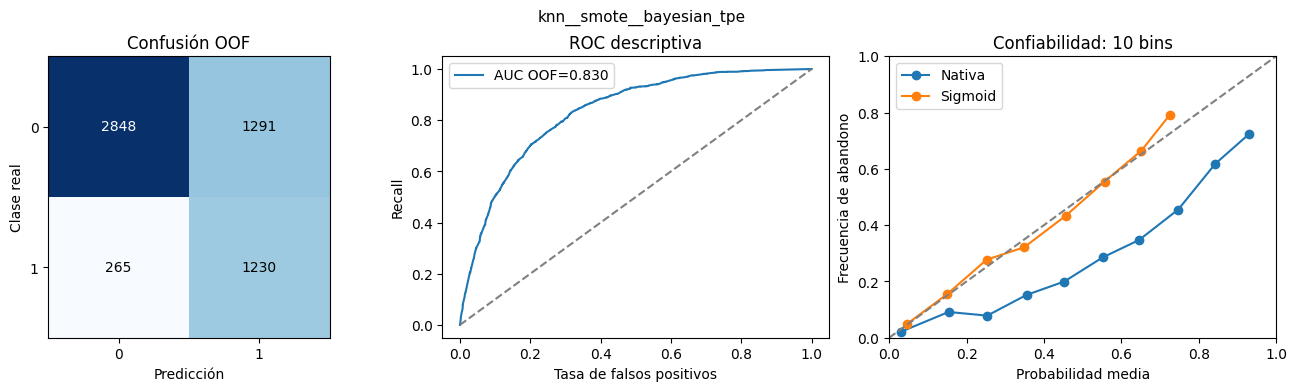

In [ ]:
panel_evaluacion('knn__smote__bayesian_tpe')

**Lectura del panel.** La matriz OOF registra TN=2848, FP=1291, FN=265 y TP=1230; los 265 falsos negativos son abandonos omitidos y las 1291 falsas alertas afectan a permanentes. La ROC representa el orden de scores a distintos umbrales; el AUC medio por fold es 0.8307, sin confundirse con el AUC de predicciones concatenadas. En confiabilidad se contrasta frecuencia observada con probabilidad asignada: Brier pasa de 0.1824 a 0.1414 y ECE de 0.1719 a 0.0219 (medias externas). La calibración se ajustó dentro de entrenamiento y no cambia el ranking principal de F1; no se selecciona una nueva variante mirando este panel.

#### Resultados de Gaussian Naive Bayes

Se contrastan los cuatro balanceos y los cuatro optimizadores usando las mismas particiones. La referencia sin balanceo permite distinguir el cambio observado sin añadir otra familia de modelos.

In [ ]:
tabla(resultados_familia('naive_bayes'))

Balanceo,Optimizador,F1 media ± DS,Recall media ± DS,Precision media ± DS,Accuracy media ± DS,AUC media ± DS,Brier nativo,ECE nativo
ADASYN,TPE,0.6090 ± 0.0177,0.8167 ± 0.0219,0.4856 ± 0.0180,0.7215 ± 0.0162,0.8310 ± 0.0093,0.237636,0.237411
ADASYN,Genético,0.6093 ± 0.0178,0.8167 ± 0.0219,0.4860 ± 0.0180,0.7219 ± 0.0162,0.8310 ± 0.0093,0.237616,0.237209
ADASYN,Grid,0.6091 ± 0.0178,0.8167 ± 0.0219,0.4858 ± 0.0181,0.7217 ± 0.0163,0.8310 ± 0.0093,0.237630,0.237127
ADASYN,Random,0.6091 ± 0.0178,0.8167 ± 0.0219,0.4858 ± 0.0181,0.7217 ± 0.0163,0.8310 ± 0.0093,0.237622,0.237273
Ponderación,TPE,0.6114 ± 0.0185,0.8067 ± 0.0253,0.4924 ± 0.0185,0.7277 ± 0.0162,0.8301 ± 0.0099,0.236166,0.237333
Ponderación,Genético,0.6116 ± 0.0196,0.8080 ± 0.0256,0.4923 ± 0.0199,0.7275 ± 0.0174,0.8300 ± 0.0097,0.236185,0.235592
Ponderación,Grid,0.6114 ± 0.0185,0.8067 ± 0.0253,0.4924 ± 0.0185,0.7277 ± 0.0162,0.8301 ± 0.0099,0.236123,0.237051
Ponderación,Random,0.6127 ± 0.0193,0.8080 ± 0.0256,0.4936 ± 0.0192,0.7288 ± 0.0166,0.8300 ± 0.0097,0.236460,0.236461
Sin balanceo,TPE,0.6197 ± 0.0169,0.7726 ± 0.0185,0.5177 ± 0.0219,0.7481 ± 0.0164,0.8301 ± 0.0097,0.214448,0.207942
Sin balanceo,Genético,0.6194 ± 0.0174,0.7732 ± 0.0203,0.5170 ± 0.0220,0.7476 ± 0.0165,0.8304 ± 0.0099,0.211640,0.204154


**Interpretación.** El mayor F1 medio observado fue **0.6198 ± 0.0180**, con Sin balanceo y Random. Hay 1 configuración(es) empatada(s) en ese máximo a precisión numérica. La mejor configuración sin balanceo obtuvo 0.6198; la diferencia descriptiva es +0.0000. Se compara el máximo de cada grupo, no un efecto causal aislado del balanceo. Recall=0.7739, Precision=0.5172 y AUC=0.8301 muestran aspectos distintos del desempeño. La selección por máximo entre configuraciones debe interpretarse con cautela. Los valores nativos de Brier/ECE se analizan junto con la rama calibrada, sin utilizarlos para seleccionar hiperparámetros.

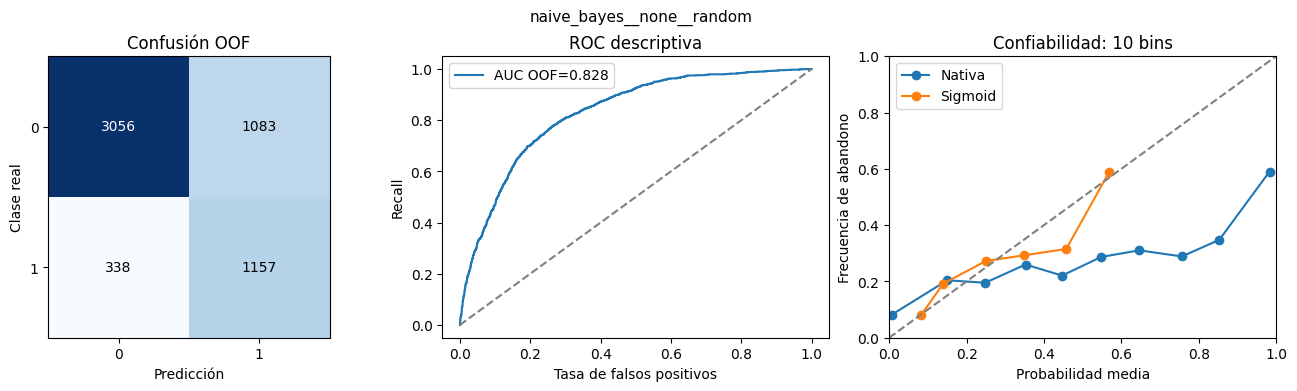

In [ ]:
panel_evaluacion('naive_bayes__none__random')

**Lectura del panel.** La matriz OOF registra TN=3056, FP=1083, FN=338 y TP=1157; los 338 falsos negativos son abandonos omitidos y las 1083 falsas alertas afectan a permanentes. La ROC representa el orden de scores a distintos umbrales; el AUC medio por fold es 0.8301, sin confundirse con el AUC de predicciones concatenadas. En confiabilidad se contrasta frecuencia observada con probabilidad asignada: Brier pasa de 0.2135 a 0.1471 y ECE de 0.2063 a 0.0278 (medias externas). La calibración se ajustó dentro de entrenamiento y no cambia el ranking principal de F1; no se selecciona una nueva variante mirando este panel.

#### Resultados de Regresión Logística

Se contrastan los cuatro balanceos y los cuatro optimizadores usando las mismas particiones. La referencia sin balanceo permite distinguir el cambio observado sin añadir otra familia de modelos.

In [ ]:
tabla(resultados_familia('logistic'))

Balanceo,Optimizador,F1 media ± DS,Recall media ± DS,Precision media ± DS,Accuracy media ± DS,AUC media ± DS,Brier nativo,ECE nativo
ADASYN,TPE,0.6223 ± 0.0176,0.8054 ± 0.0181,0.5075 ± 0.0220,0.7403 ± 0.0180,0.8421 ± 0.0092,0.173626,0.181705
ADASYN,Genético,0.6213 ± 0.0144,0.8147 ± 0.0158,0.5027 ± 0.0229,0.7361 ± 0.0187,0.8434 ± 0.0092,0.172609,0.176879
ADASYN,Grid,0.6229 ± 0.0181,0.8000 ± 0.0198,0.5103 ± 0.0220,0.7426 ± 0.0178,0.8405 ± 0.0101,0.175171,0.185483
ADASYN,Random,0.6222 ± 0.0173,0.8140 ± 0.0215,0.5036 ± 0.0179,0.7375 ± 0.0152,0.8430 ± 0.0109,0.172860,0.177177
Ponderación,TPE,0.6308 ± 0.0176,0.7920 ± 0.0163,0.5242 ± 0.0183,0.7538 ± 0.0143,0.8438 ± 0.0108,0.164755,0.152792
Ponderación,Genético,0.6321 ± 0.0172,0.7940 ± 0.0168,0.5252 ± 0.0198,0.7545 ± 0.0150,0.8436 ± 0.0113,0.164693,0.153407
Ponderación,Grid,0.6324 ± 0.0170,0.7920 ± 0.0124,0.5267 ± 0.0223,0.7554 ± 0.0165,0.8439 ± 0.0098,0.164560,0.152510
Ponderación,Random,0.6313 ± 0.0174,0.7933 ± 0.0163,0.5244 ± 0.0189,0.7540 ± 0.0145,0.8433 ± 0.0113,0.164795,0.153688
Sin balanceo,TPE,0.5979 ± 0.0109,0.5492 ± 0.0159,0.6578 ± 0.0362,0.8039 ± 0.0103,0.8458 ± 0.0092,0.135005,0.022722
Sin balanceo,Genético,0.5965 ± 0.0120,0.5478 ± 0.0156,0.6563 ± 0.0376,0.8032 ± 0.0110,0.8458 ± 0.0092,0.135023,0.023667


**Interpretación.** El mayor F1 medio observado fue **0.6340 ± 0.0188**, con SMOTE y Grid. Hay 1 configuración(es) empatada(s) en ese máximo a precisión numérica. La mejor configuración sin balanceo obtuvo 0.5979; la diferencia descriptiva es +0.0361. Se compara el máximo de cada grupo, no un efecto causal aislado del balanceo. Recall=0.7806, Precision=0.5343 y AUC=0.8441 muestran aspectos distintos del desempeño. La selección por máximo entre configuraciones debe interpretarse con cautela. Los valores nativos de Brier/ECE se analizan junto con la rama calibrada, sin utilizarlos para seleccionar hiperparámetros.

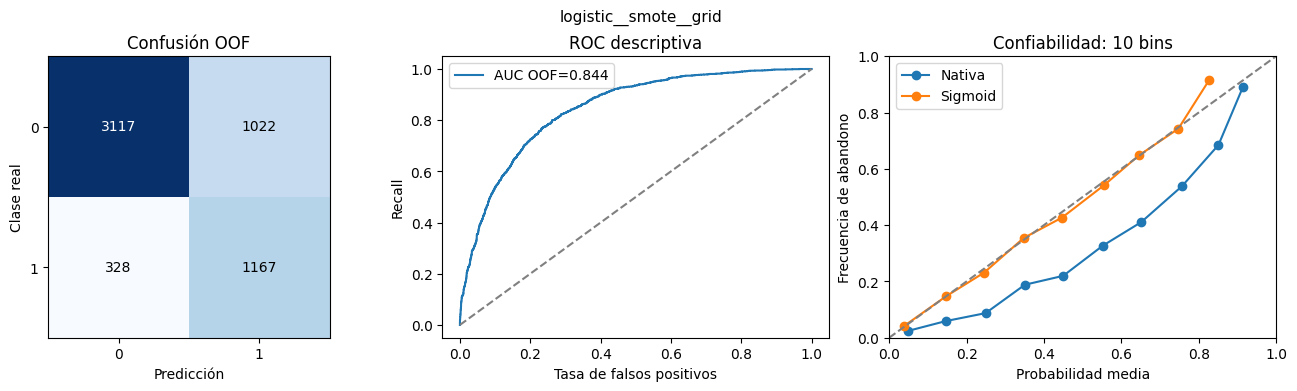

In [ ]:
panel_evaluacion('logistic__smote__grid')

**Lectura del panel.** La matriz OOF registra TN=3117, FP=1022, FN=328 y TP=1167; los 328 falsos negativos son abandonos omitidos y las 1022 falsas alertas afectan a permanentes. La ROC representa el orden de scores a distintos umbrales; el AUC medio por fold es 0.8441, sin confundirse con el AUC de predicciones concatenadas. En confiabilidad se contrasta frecuencia observada con probabilidad asignada: Brier pasa de 0.1625 a 0.1356 y ECE de 0.1442 a 0.0240 (medias externas). La calibración se ajustó dentro de entrenamiento y no cambia el ranking principal de F1; no se selecciona una nueva variante mirando este panel.

#### Resultados de Decision Tree

Se contrastan los cuatro balanceos y los cuatro optimizadores usando las mismas particiones. La referencia sin balanceo permite distinguir el cambio observado sin añadir otra familia de modelos.

In [ ]:
tabla(resultados_familia('decision_tree'))

Balanceo,Optimizador,F1 media ± DS,Recall media ± DS,Precision media ± DS,Accuracy media ± DS,AUC media ± DS,Brier nativo,ECE nativo
ADASYN,TPE,0.6013 ± 0.0225,0.8194 ± 0.0456,0.4757 ± 0.0236,0.7116 ± 0.0224,0.8084 ± 0.0115,0.175174,0.134450
ADASYN,Genético,0.6013 ± 0.0225,0.8194 ± 0.0456,0.4757 ± 0.0236,0.7116 ± 0.0224,0.8084 ± 0.0115,0.175174,0.134450
ADASYN,Grid,0.6013 ± 0.0225,0.8194 ± 0.0456,0.4757 ± 0.0236,0.7116 ± 0.0224,0.8084 ± 0.0115,0.175174,0.134450
ADASYN,Random,0.6013 ± 0.0225,0.8194 ± 0.0456,0.4757 ± 0.0236,0.7116 ± 0.0224,0.8084 ± 0.0115,0.175174,0.134450
Ponderación,TPE,0.6055 ± 0.0268,0.7953 ± 0.0462,0.4893 ± 0.0240,0.7251 ± 0.0201,0.8251 ± 0.0121,0.173859,0.145143
Ponderación,Genético,0.6055 ± 0.0268,0.7953 ± 0.0462,0.4893 ± 0.0240,0.7251 ± 0.0201,0.8251 ± 0.0121,0.173859,0.145143
Ponderación,Grid,0.6055 ± 0.0268,0.7953 ± 0.0462,0.4893 ± 0.0240,0.7251 ± 0.0201,0.8251 ± 0.0121,0.173859,0.145143
Ponderación,Random,0.6055 ± 0.0268,0.7953 ± 0.0462,0.4893 ± 0.0240,0.7251 ± 0.0201,0.8251 ± 0.0121,0.173859,0.145143
Sin balanceo,TPE,0.5892 ± 0.0362,0.6181 ± 0.0354,0.5639 ± 0.0449,0.7709 ± 0.0251,0.8022 ± 0.0222,0.150477,0.031750
Sin balanceo,Genético,0.5892 ± 0.0362,0.6181 ± 0.0354,0.5639 ± 0.0449,0.7709 ± 0.0251,0.8022 ± 0.0222,0.150477,0.031750


**Interpretación.** El mayor F1 medio observado fue **0.6119 ± 0.0093**, con SMOTE y TPE. Hay 4 configuración(es) empatada(s) en ese máximo a precisión numérica. La mejor configuración sin balanceo obtuvo 0.5892; la diferencia descriptiva es +0.0228. Se compara el máximo de cada grupo, no un efecto causal aislado del balanceo. Recall=0.7304, Precision=0.5270 y AUC=0.8242 muestran aspectos distintos del desempeño. La selección por máximo entre configuraciones debe interpretarse con cautela. Los valores nativos de Brier/ECE se analizan junto con la rama calibrada, sin utilizarlos para seleccionar hiperparámetros.

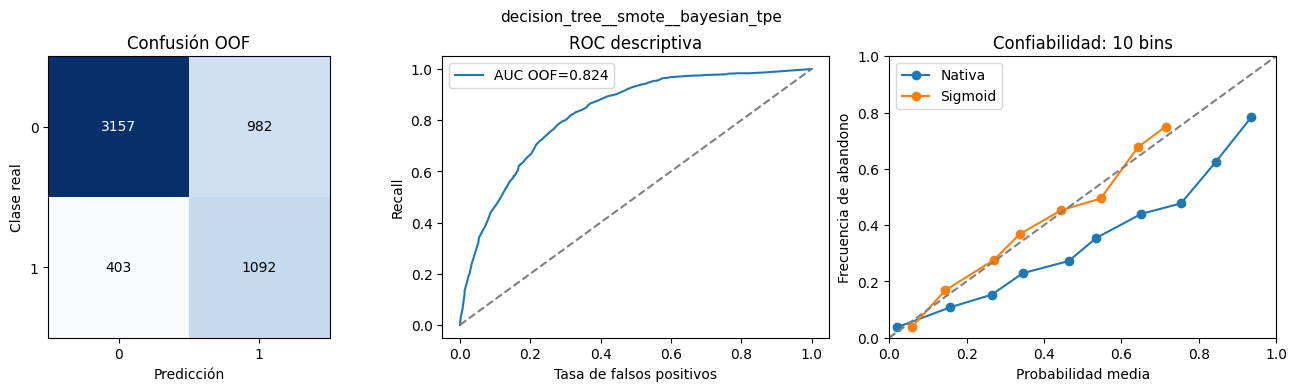

In [ ]:
panel_evaluacion('decision_tree__smote__bayesian_tpe')

**Lectura del panel.** La matriz OOF registra TN=3157, FP=982, FN=403 y TP=1092; los 403 falsos negativos son abandonos omitidos y las 982 falsas alertas afectan a permanentes. La ROC representa el orden de scores a distintos umbrales; el AUC medio por fold es 0.8242, sin confundirse con el AUC de predicciones concatenadas. En confiabilidad se contrasta frecuencia observada con probabilidad asignada: Brier pasa de 0.1672 a 0.1442 y ECE de 0.1276 a 0.0371 (medias externas). La calibración se ajustó dentro de entrenamiento y no cambia el ranking principal de F1; no se selecciona una nueva variante mirando este panel.

#### Resultados de Random Forest

Se contrastan los cuatro balanceos y los cuatro optimizadores usando las mismas particiones. La referencia sin balanceo permite distinguir el cambio observado sin añadir otra familia de modelos.

In [ ]:
tabla(resultados_familia('random_forest'))

Balanceo,Optimizador,F1 media ± DS,Recall media ± DS,Precision media ± DS,Accuracy media ± DS,AUC media ± DS,Brier nativo,ECE nativo
ADASYN,TPE,0.6226 ± 0.0146,0.7398 ± 0.0367,0.5385 ± 0.0219,0.7620 ± 0.0143,0.8420 ± 0.0071,0.155607,0.120915
ADASYN,Genético,0.6226 ± 0.0146,0.7398 ± 0.0367,0.5385 ± 0.0219,0.7620 ± 0.0143,0.8420 ± 0.0071,0.155607,0.120915
ADASYN,Grid,0.6226 ± 0.0146,0.7398 ± 0.0367,0.5385 ± 0.0219,0.7620 ± 0.0143,0.8420 ± 0.0071,0.155607,0.120915
ADASYN,Random,0.6226 ± 0.0146,0.7398 ± 0.0367,0.5385 ± 0.0219,0.7620 ± 0.0143,0.8420 ± 0.0071,0.155607,0.120915
Ponderación,TPE,0.6338 ± 0.0121,0.7585 ± 0.0148,0.5444 ± 0.0146,0.7673 ± 0.0101,0.8454 ± 0.0086,0.153934,0.120149
Ponderación,Genético,0.6338 ± 0.0121,0.7585 ± 0.0148,0.5444 ± 0.0146,0.7673 ± 0.0101,0.8454 ± 0.0086,0.153934,0.120149
Ponderación,Grid,0.6338 ± 0.0121,0.7585 ± 0.0148,0.5444 ± 0.0146,0.7673 ± 0.0101,0.8454 ± 0.0086,0.153934,0.120149
Ponderación,Random,0.6338 ± 0.0121,0.7585 ± 0.0148,0.5444 ± 0.0146,0.7673 ± 0.0101,0.8454 ± 0.0086,0.153934,0.120149
Sin balanceo,TPE,0.5741 ± 0.0149,0.5057 ± 0.0273,0.6662 ± 0.0324,0.8010 ± 0.0077,0.8390 ± 0.0119,0.137173,0.028636
Sin balanceo,Genético,0.5741 ± 0.0149,0.5057 ± 0.0273,0.6662 ± 0.0324,0.8010 ± 0.0077,0.8390 ± 0.0119,0.137173,0.028636


**Interpretación.** El mayor F1 medio observado fue **0.6384 ± 0.0227**, con SMOTE y TPE. Hay 4 configuración(es) empatada(s) en ese máximo a precisión numérica. La mejor configuración sin balanceo obtuvo 0.5741; la diferencia descriptiva es +0.0644. Se compara el máximo de cada grupo, no un efecto causal aislado del balanceo. Recall=0.7351, Precision=0.5646 y AUC=0.8438 muestran aspectos distintos del desempeño. La selección por máximo entre configuraciones debe interpretarse con cautela. Los valores nativos de Brier/ECE se analizan junto con la rama calibrada, sin utilizarlos para seleccionar hiperparámetros.

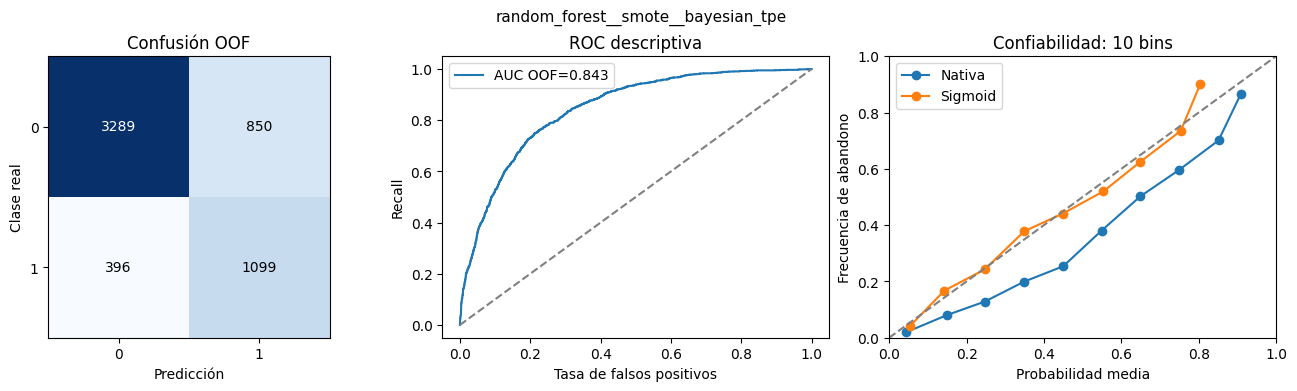

In [ ]:
panel_evaluacion('random_forest__smote__bayesian_tpe')

**Lectura del panel.** La matriz OOF registra TN=3289, FP=850, FN=396 y TP=1099; los 396 falsos negativos son abandonos omitidos y las 850 falsas alertas afectan a permanentes. La ROC representa el orden de scores a distintos umbrales; el AUC medio por fold es 0.8438, sin confundirse con el AUC de predicciones concatenadas. En confiabilidad se contrasta frecuencia observada con probabilidad asignada: Brier pasa de 0.1515 a 0.1363 y ECE de 0.1106 a 0.0292 (medias externas). La calibración se ajustó dentro de entrenamiento y no cambia el ranking principal de F1; no se selecciona una nueva variante mirando este panel.

#### Resultados de XGBoost

Se contrastan los cuatro balanceos y los cuatro optimizadores usando las mismas particiones. La referencia sin balanceo permite distinguir el cambio observado sin añadir otra familia de modelos.

In [ ]:
tabla(resultados_familia('xgboost'))

Balanceo,Optimizador,F1 media ± DS,Recall media ± DS,Precision media ± DS,Accuracy media ± DS,AUC media ± DS,Brier nativo,ECE nativo
ADASYN,TPE,0.6285 ± 0.0158,0.7538 ± 0.0252,0.5398 ± 0.0268,0.7632 ± 0.0177,0.8440 ± 0.0084,0.152142,0.111942
ADASYN,Genético,0.6316 ± 0.0197,0.7478 ± 0.0529,0.5482 ± 0.0194,0.7689 ± 0.0122,0.8437 ± 0.0092,0.150512,0.102941
ADASYN,Grid,0.6252 ± 0.0093,0.7358 ± 0.0140,0.5437 ± 0.0122,0.7659 ± 0.0079,0.8442 ± 0.0083,0.150024,0.103376
ADASYN,Random,0.6266 ± 0.0177,0.7505 ± 0.0220,0.5388 ± 0.0315,0.7622 ± 0.0196,0.8434 ± 0.0091,0.152013,0.108792
Ponderación,TPE,0.6331 ± 0.0158,0.8194 ± 0.0136,0.5159 ± 0.0179,0.7478 ± 0.0146,0.8465 ± 0.0092,0.163745,0.151799
Ponderación,Genético,0.6269 ± 0.0170,0.7779 ± 0.0370,0.5255 ± 0.0164,0.7543 ± 0.0126,0.8430 ± 0.0105,0.160764,0.128049
Ponderación,Grid,0.6267 ± 0.0180,0.7940 ± 0.0448,0.5181 ± 0.0093,0.7494 ± 0.0077,0.8453 ± 0.0130,0.161467,0.138195
Ponderación,Random,0.6307 ± 0.0179,0.8067 ± 0.0168,0.5178 ± 0.0173,0.7492 ± 0.0141,0.8466 ± 0.0092,0.162373,0.143383
Sin balanceo,TPE,0.5845 ± 0.0216,0.5211 ± 0.0215,0.6680 ± 0.0520,0.8032 ± 0.0151,0.8469 ± 0.0086,0.134445,0.029692
Sin balanceo,Genético,0.5882 ± 0.0176,0.5284 ± 0.0223,0.6658 ± 0.0467,0.8035 ± 0.0131,0.8459 ± 0.0092,0.134915,0.027639


**Interpretación.** El mayor F1 medio observado fue **0.6380 ± 0.0206**, con SMOTE y Random. Hay 1 configuración(es) empatada(s) en ese máximo a precisión numérica. La mejor configuración sin balanceo obtuvo 0.5887; la diferencia descriptiva es +0.0493. Se compara el máximo de cada grupo, no un efecto causal aislado del balanceo. Recall=0.7452, Precision=0.5585 y AUC=0.8461 muestran aspectos distintos del desempeño. La selección por máximo entre configuraciones debe interpretarse con cautela. Los valores nativos de Brier/ECE se analizan junto con la rama calibrada, sin utilizarlos para seleccionar hiperparámetros.

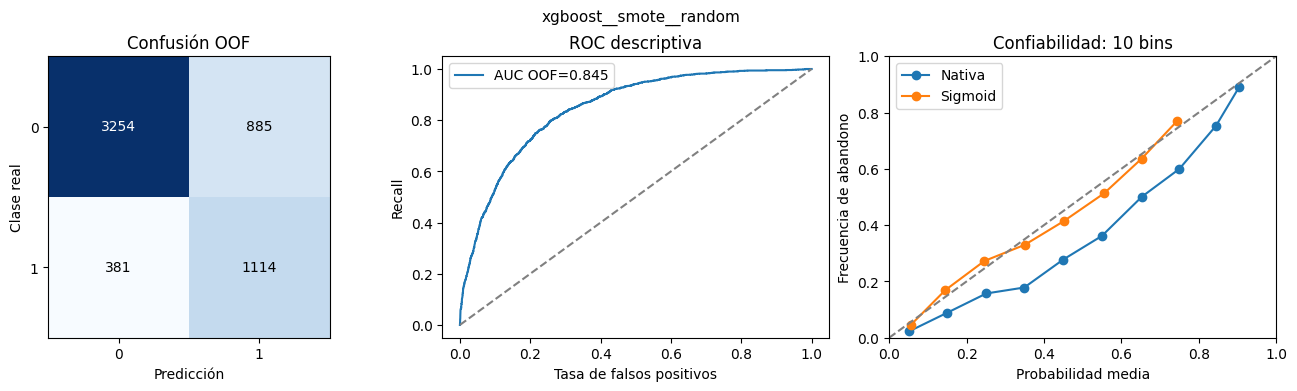

In [ ]:
panel_evaluacion('xgboost__smote__random')

**Lectura del panel.** La matriz OOF registra TN=3254, FP=885, FN=381 y TP=1114; los 381 falsos negativos son abandonos omitidos y las 885 falsas alertas afectan a permanentes. La ROC representa el orden de scores a distintos umbrales; el AUC medio por fold es 0.8461, sin confundirse con el AUC de predicciones concatenadas. En confiabilidad se contrasta frecuencia observada con probabilidad asignada: Brier pasa de 0.1493 a 0.1357 y ECE de 0.1030 a 0.0303 (medias externas). La calibración se ajustó dentro de entrenamiento y no cambia el ranking principal de F1; no se selecciona una nueva variante mirando este panel.

#### Resultados de SVM RBF

Se contrastan los cuatro balanceos y los cuatro optimizadores usando las mismas particiones. La referencia sin balanceo permite distinguir el cambio observado sin añadir otra familia de modelos.

In [ ]:
tabla(resultados_familia('svm'))

Balanceo,Optimizador,F1 media ± DS,Recall media ± DS,Precision media ± DS,Accuracy media ± DS,AUC media ± DS,Brier nativo,ECE nativo
ADASYN,TPE,0.6181 ± 0.0223,0.7893 ± 0.0441,0.5104 ± 0.0404,0.7401 ± 0.0321,0.8348 ± 0.0073,nan,nan
ADASYN,Genético,0.6194 ± 0.0189,0.8013 ± 0.0220,0.5049 ± 0.0181,0.7386 ± 0.0155,0.8370 ± 0.0093,nan,nan
ADASYN,Grid,0.6147 ± 0.0162,0.8033 ± 0.0196,0.4982 ± 0.0201,0.7325 ± 0.0172,0.8368 ± 0.0086,nan,nan
ADASYN,Random,0.6180 ± 0.0189,0.8187 ± 0.0408,0.4973 ± 0.0250,0.7311 ± 0.0226,0.8387 ± 0.0106,nan,nan
Ponderación,TPE,0.6254 ± 0.0170,0.7893 ± 0.0157,0.5181 ± 0.0203,0.7488 ± 0.0156,0.8403 ± 0.0098,nan,nan
Ponderación,Genético,0.6280 ± 0.0158,0.7860 ± 0.0132,0.5232 ± 0.0198,0.7527 ± 0.0148,0.8366 ± 0.0131,nan,nan
Ponderación,Grid,0.6255 ± 0.0192,0.7839 ± 0.0179,0.5205 ± 0.0198,0.7508 ± 0.0152,0.8385 ± 0.0101,nan,nan
Ponderación,Random,0.6268 ± 0.0164,0.7766 ± 0.0137,0.5258 ± 0.0219,0.7543 ± 0.0163,0.8385 ± 0.0097,nan,nan
Sin balanceo,TPE,0.5776 ± 0.0311,0.5217 ± 0.0289,0.6489 ± 0.0533,0.7973 ± 0.0183,0.8291 ± 0.0239,nan,nan
Sin balanceo,Genético,0.5739 ± 0.0260,0.5117 ± 0.0277,0.6561 ± 0.0546,0.7982 ± 0.0162,0.8236 ± 0.0207,nan,nan


**Interpretación.** El mayor F1 medio observado fue **0.6307 ± 0.0190**, con SMOTE y Genético. Hay 1 configuración(es) empatada(s) en ese máximo a precisión numérica. La mejor configuración sin balanceo obtuvo 0.5776; la diferencia descriptiva es +0.0531. Se compara el máximo de cada grupo, no un efecto causal aislado del balanceo. Recall=0.7786, Precision=0.5304 y AUC=0.8392 muestran aspectos distintos del desempeño. La selección por máximo entre configuraciones debe interpretarse con cautela. En SVM, Brier/ECE nativos no aplican: su margen no es una probabilidad; se evalúa su rama sigmoid más adelante.

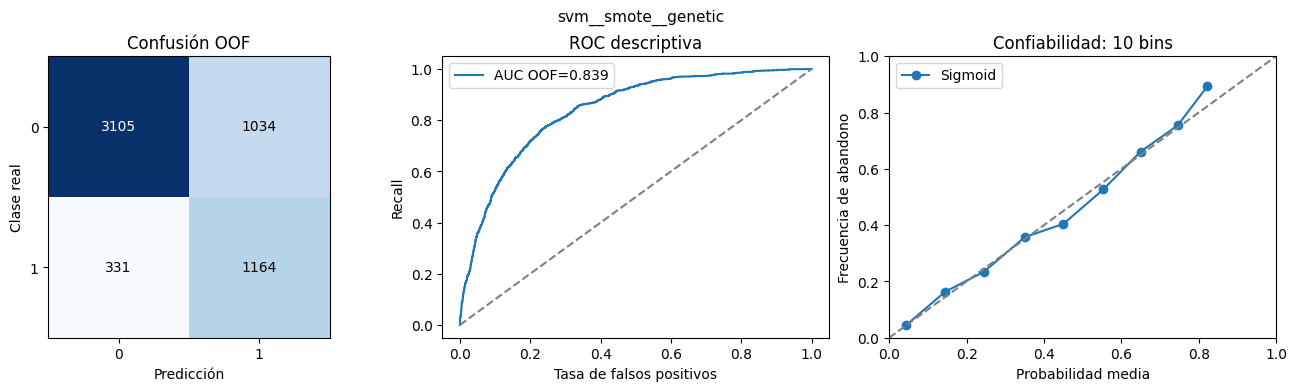

In [ ]:
panel_evaluacion('svm__smote__genetic')

**Lectura del panel.** La matriz OOF registra TN=3105, FP=1034, FN=331 y TP=1164; los 331 falsos negativos son abandonos omitidos y las 1034 falsas alertas afectan a permanentes. La ROC representa el orden de scores a distintos umbrales; el AUC medio por fold es 0.8392, sin confundirse con el AUC de predicciones concatenadas. En confiabilidad se contrasta frecuencia observada con probabilidad asignada: La rama sigmoid tiene Brier=0.1374 y ECE=0.0224; no se inventa una comparación con probabilidades nativas inexistentes. La calibración se ajustó dentro de entrenamiento y no cambia el ranking principal de F1; no se selecciona una nueva variante mirando este panel.

### 1.8 Síntesis de los resultados de calibración

La tabla siguiente reúne las mismas siete configuraciones representativas: no se elige una nueva configuración por su Brier. Una reducción en Brier/ECE no garantiza mejora de F1 con el umbral predeterminado.

In [ ]:
CALIBRACION=PRINCIPAL.groupby('experiment_id')[['brier','ece','cal_brier','cal_ece']].mean().reset_index()
CALIBRACION['delta_brier']=CALIBRACION.cal_brier-CALIBRACION.brier
CALIBRACION['delta_ece']=CALIBRACION.cal_ece-CALIBRACION.ece
tabla(REPRESENTANTES[['model','experiment_id']].merge(CALIBRACION,on='experiment_id')[['model','brier','cal_brier','delta_brier','ece','cal_ece','delta_ece']])

model,brier,cal_brier,delta_brier,ece,cal_ece,delta_ece
knn,0.182422,0.141382,-0.041040,0.171907,0.021850,-0.150056
naive_bayes,0.213502,0.147100,-0.066402,0.206323,0.027783,-0.178540
logistic,0.162460,0.135551,-0.026909,0.144164,0.024028,-0.120135
decision_tree,0.167224,0.144154,-0.023070,0.127564,0.037105,-0.090458
random_forest,0.151500,0.136309,-0.015191,0.110593,0.029157,-0.081436
xgboost,0.149327,0.135692,-0.013635,0.103044,0.030251,-0.072793
svm,nan,0.137434,nan,nan,0.022380,nan


**Interpretación.** Los deltas son calibrado menos nativo: valores negativos indican reducción del error. En el universo completo, Brier y ECE disminuyeron conjuntamente en **80 de las 96 configuraciones con probabilidades nativas**; no hubo mejora universal. Las otras 16 son SVM y requieren la rama sigmoid para estas métricas. La evaluación ya incluye recalibración donde corresponde; no se reajusta sigmoid usando los resultados mostrados.

### 1.9 Robustez algorítmica e intervalos de confianza

Las tres realizaciones comparten folds, pero varían las semillas de optimización, modelo y remuestreo. Se muestran las medias externas por realización de los representantes elegidos usando solo la realización principal. La dispersión entre ellas describe sensibilidad algorítmica con particiones fijas; no estima variación por obtener otros clientes.

Los IC de F1 ya guardados emplean 2.000 remuestreos estratificados condicionales por fold, con modelos fijos. El remuestreo equivalente de conteos de confusión evita materializar filas repetidas. Se agregan para el estimando de media condicional de los folds. No incorporan reentrenamiento, selección entre 112 configuraciones ni incertidumbre por nuevos folds y no se utilizan como pruebas de superioridad.

In [ ]:
def conditional_f1_intervals(units,draws=2000):
    """Bootstrap estratificado condicional de sujetos, con modelos fijos."""
    intervals=[]
    for eid,g in units.groupby('experiment_id'):
        samples=[]
        for r in g.sort_values('outer_fold').itertuples():
            rng=np.random.default_rng(np.random.SeedSequence([42,101,int(r.outer_fold)]))
            pos=int(r.tp+r.fn); neg=int(r.tn+r.fp)
            tp=rng.binomial(pos,r.tp/pos,draws); fp=rng.binomial(neg,r.fp/neg,draws)
            f1=2*tp/(pos+tp+fp); samples.append(f1)
            low,high=np.quantile(f1,[.025,.975])
            intervals.append({'experiment_id':eid,'scope':'fold','fold':r.outer_fold,'low':low,'high':high,'draws':draws})
        low,high=np.quantile(np.mean(samples,axis=0),[.025,.975])
        intervals.append({'experiment_id':eid,'scope':'conditional_mean','fold':-1,'low':low,'high':high,'draws':draws})
    return pd.DataFrame(intervals)

In [ ]:
SEMILLAS=UNIDADES.groupby(['experiment_id','replicate']).f1_positive.agg(['mean','std']).reset_index()
IC=leer_tabla('ic_f1_condicional.csv') if not RECALCULAR_COSTOSO else conditional_f1_intervals(PRINCIPAL)
vista=REPRESENTANTES[['model','experiment_id','f1_positive_mean','f1_positive_std']].merge(SEMILLAS.pivot(index='experiment_id',columns='replicate',values='mean').rename(columns={0:'F1 semilla 0',1:'F1 semilla 1',2:'F1 semilla 2'}),on='experiment_id').merge(IC[IC.scope=='conditional_mean'][['experiment_id','low','high']],on='experiment_id')
tabla(vista.drop(columns='experiment_id'))

model,f1_positive_mean,f1_positive_std,F1 semilla 0,F1 semilla 1,F1 semilla 2,low,high
knn,0.612558,0.011775,0.612558,0.614669,0.614094,0.598891,0.626232
naive_bayes,0.619778,0.018036,0.619778,0.620273,0.619286,0.604782,0.634280
logistic,0.633953,0.018815,0.633953,0.629117,0.630971,0.619104,0.648796
decision_tree,0.611928,0.009268,0.611928,0.600635,0.603422,0.595950,0.628098
random_forest,0.638421,0.022715,0.638421,0.635334,0.631245,0.620984,0.654315
xgboost,0.637990,0.020556,0.637990,0.630217,0.635326,0.620321,0.653019
svm,0.630705,0.019006,0.630705,0.629668,0.623302,0.615201,0.646284


**Interpretación.** La DS externa resume cinco folds de una realización; las columnas por semilla resumen variación algorítmica sobre los mismos folds. `low` y `high` delimitan IC condicionales del 95 %. Solapamiento o separación visual no constituye un contraste pareado válido. Los empates entre optimizadores en espacios agotados pueden coexistir con cambios entre realizaciones, debido a modelo o remuestreo.

## 2. Comparación de métodos de optimización

### 2.1 Calidad interna a igual presupuesto y convergencia

Se emparejan búsquedas por modelo, balanceo, realización y fold. A 8, 16 y 24 evaluaciones se compara el mejor F1 interno acumulado y el tiempo con Grid. Son 420 comparaciones por optimizador y presupuesto. Esta lectura responde a eficiencia de búsqueda; no reemplaza las métricas externas ya presentadas.

In [ ]:
TRAZAS=leer_tabla('anytime.csv')
keys=['model','balance','replicate','outer_fold','evaluation']
grid=TRAZAS[TRAZAS.optimizer=='grid'][keys+['best_inner_f1','seconds']]
comparacion=TRAZAS.merge(grid,on=keys,suffixes=('','_grid'))
comparacion['gain_f1_vs_grid']=comparacion.best_inner_f1-comparacion.best_inner_f1_grid
comparacion['time_ratio_vs_grid']=comparacion.seconds/comparacion.seconds_grid
EFICIENCIA=comparacion[comparacion.evaluation.isin([8,16,24])].groupby(['optimizer','evaluation']).agg(
    mean_f1_gain=('gain_f1_vs_grid','mean'),median_time_ratio=('time_ratio_vs_grid','median'),
    fraction_higher=('gain_f1_vs_grid',lambda x: float((x>1e-12).mean())),comparisons=('gain_f1_vs_grid','size')).reset_index()
tabla(EFICIENCIA)

optimizer,evaluation,mean_f1_gain,median_time_ratio,fraction_higher,comparisons
bayesian_tpe,8,0.006853,1.077859,0.519048,420
bayesian_tpe,16,0.000925,1.040511,0.511905,420
bayesian_tpe,24,0.000353,0.997345,0.347619,420
genetic,8,0.006322,1.064522,0.478571,420
genetic,16,0.000363,1.043481,0.426190,420
genetic,24,-0.000054,0.999089,0.261905,420
grid,8,0.000000,1.000000,0.000000,420
grid,16,0.000000,1.000000,0.000000,420
grid,24,0.000000,1.000000,0.000000,420
random,8,0.006559,1.061655,0.509524,420


**Interpretación.** A ocho evaluaciones, TPE, Genético y Random aventajan descriptivamente a Grid en F1 interno medio en 0,00685, 0,00632 y 0,00656. A 24, las diferencias son 0,00035, −0,00005 y −0,00033, con razones medianas de tiempo próximas a uno. No se observa una ventaja universal de calidad o velocidad. El orden de Grid, los rangos continuos y el agotamiento de dominios finitos condicionan la comparación; estos deltas internos no son ganancias de generalización.

In [ ]:
def grafico_anytime(por_tiempo=False):
    """Resume el mejor F1 interno por evaluación y luego por familia."""
    series=TRAZAS.groupby(['model','balance','optimizer','evaluation']).agg(f1=('best_inner_f1','mean'),seconds=('seconds','mean')).reset_index()
    fig,axes=plt.subplots(2,4,figsize=(15,7),layout='constrained')
    for ax,(model,g) in zip(axes.flat,series.groupby('model')):
        for opt,datos in g.groupby('optimizer'):
            curve=datos.groupby('evaluation')[['f1','seconds']].mean()
            ax.plot(curve.seconds if por_tiempo else curve.index,curve.f1,label=opt)
        ax.set(title=model,xlabel='Tiempo acumulado (s)' if por_tiempo else 'Evaluaciones únicas',ylabel='Mejor F1 interno')
    axes.flat[-1].axis('off'); axes.flat[-1].legend(*axes.flat[0].get_legend_handles_labels(),loc='center')
    plt.show(); plt.close(fig)

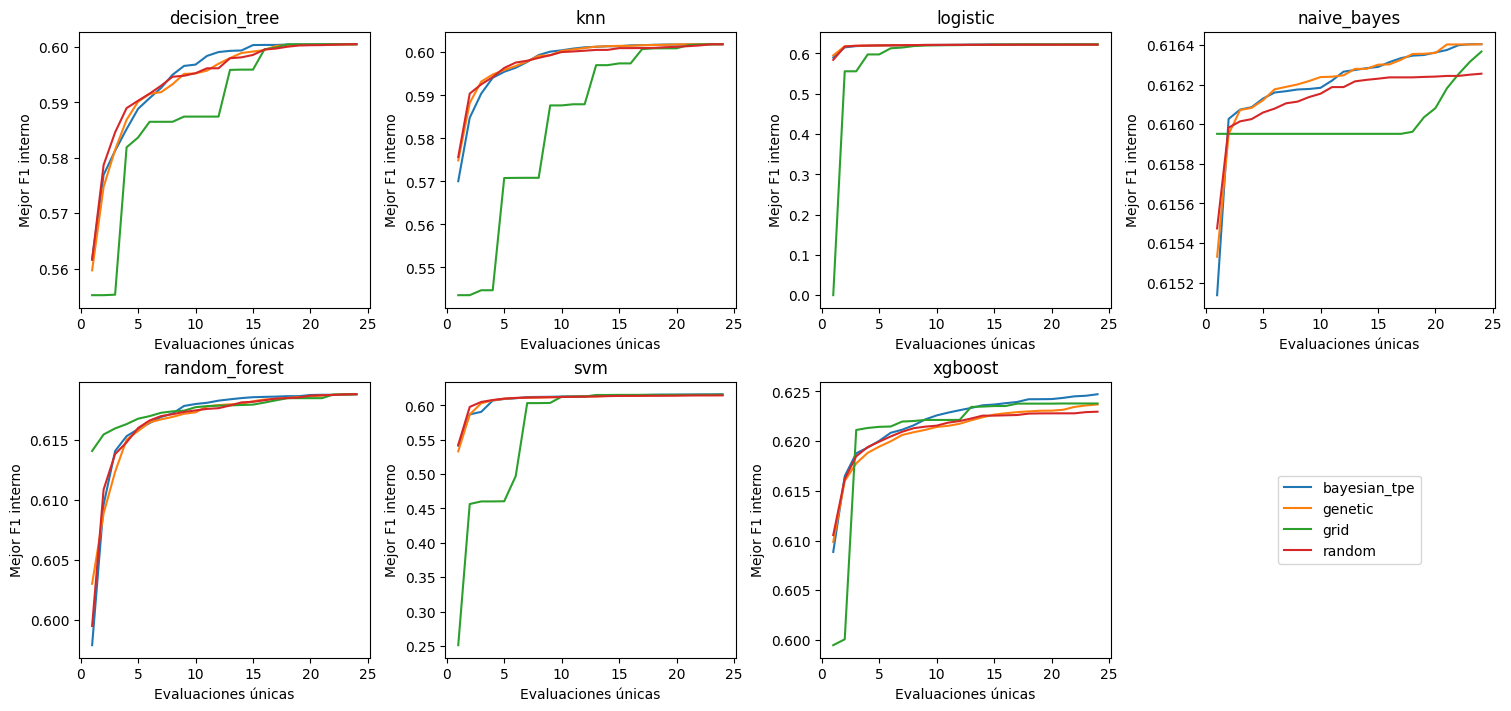

In [ ]:
grafico_anytime()

**Interpretación.** Cada trayectoria muestra el mejor F1 interno medio acumulado por familia y evaluaciones únicas. Las subidas indican que se encontró un candidato interno mejor; una meseta significa ausencia de mejora dentro del presupuesto visitado. En dominios finitos agotados, el mismo resultado final no distingue eficiencia temprana ni prueba equivalencia de los algoritmos en otros espacios.

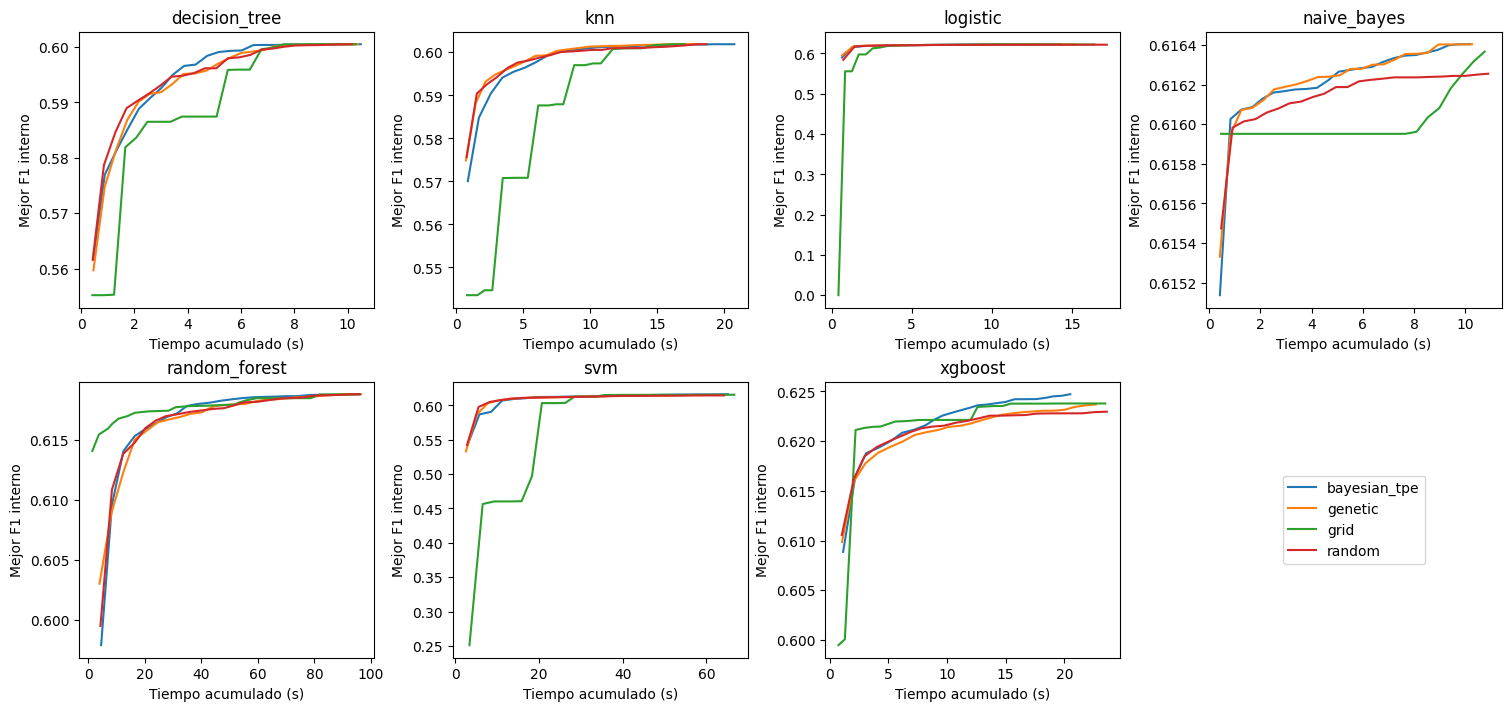

In [ ]:
grafico_anytime(por_tiempo=True)

**Interpretación.** El eje temporal permite observar el coste de alcanzar los valores internos, que varía entre familias. Las trayectorias combinan búsquedas emparejadas pero no forman un experimento con presupuestos temporales iguales. La carga del equipo y los hiperparámetros influyen en los tiempos; no se atribuye causalmente a un optimizador cualquier separación visual.

#### Diversidad del algoritmo genético

Se registró la fracción de genotipos únicos y la distancia normalizada entre individuos. En genes continuos se usa distancia en su representación normalizada y en categorías discrepancia entre índices. Estas medidas detectan pérdida de diversidad sin evaluar otra vez los modelos.

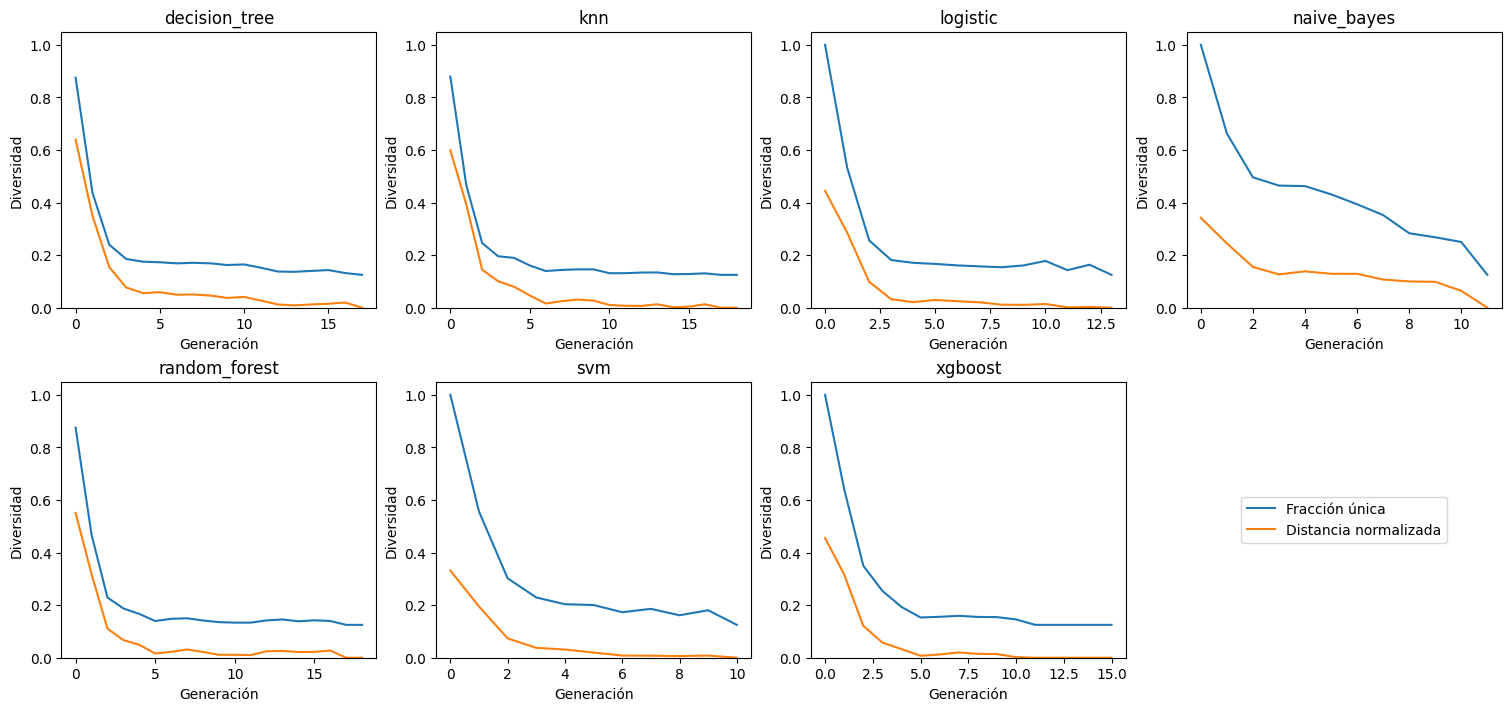

In [ ]:
DIVERSIDAD=leer_tabla('diversidad.csv')
DIVERSIDAD['model']=DIVERSIDAD.experiment_id.str.split('__').str[0]
div=DIVERSIDAD.groupby(['model','generation']).agg(unique_fraction=('unique_fraction','mean'),
    mean_distance=('mean_normalized_distance','mean'),searches=('experiment_id','size')).reset_index()
fig,axes=plt.subplots(2,4,figsize=(15,7),layout='constrained')
for ax,(model,g) in zip(axes.flat,div.groupby('model')):
    ax.plot(g.generation,g.unique_fraction,label='Fracción única')
    ax.plot(g.generation,g.mean_distance,label='Distancia normalizada')
    ax.set(title=model,xlabel='Generación',ylabel='Diversidad',ylim=(0,1.05))
axes.flat[-1].axis('off'); axes.flat[-1].legend(*axes.flat[0].get_legend_handles_labels(),loc='center')
plt.show(); plt.close(fig)

**Interpretación.** La fracción única y la distancia describen aspectos diferentes: individuos distintos pueden estar cerca en el espacio genético. Elitismo conserva el mejor fitness; mutación y el inmigrante de rescate permiten introducir novedad. Las medias por generación incluyen solo búsquedas que llegaron a esa generación, de modo que no se interpretan como una única población longitudinal ni como evidencia de convergencia global.

### 2.2 Presupuesto y coste empírico

Las 40.320 evaluaciones de candidatos requirieron 120.960 ajustes internos. Se añadieron 1.680 reajustes externos y 6.720 ajustes de la rama calibrada: **129.360 ajustes lógicos oficiales**. Los 219 ajustes posteriores de modelos finales y los benchmarks auxiliares se contabilizan aparte; no amplían las 112 configuraciones ni sus 1.680 resultados externos.

Los tiempos de búsqueda, reajuste y predicción se registraron por separado. La suma de tiempos de búsqueda no es necesariamente el tiempo de calendario de la sesión completa: excluye pausas y parte de gestión de archivos. RSS es memoria muestreada del proceso y sus hijos, no memoria incremental exclusiva de cada algoritmo.

In [ ]:
COSTE=UNIDADES.groupby(['model','optimizer']).agg(search_mean=('search_seconds','mean'),search_std=('search_seconds','std'),
    refit_mean=('refit_seconds','mean'),inference_mean=('predict_seconds','mean'),rss_mean_mib=('rss_peak_mib','mean'),
    evaluations=('evaluations','sum'),proposals=('proposals','sum')).reset_index()
COSTE['seconds_per_evaluation']=COSTE.search_mean/24
tabla(COSTE)

model,optimizer,search_mean,search_std,refit_mean,inference_mean,rss_mean_mib,evaluations,proposals,seconds_per_evaluation
decision_tree,bayesian_tpe,10.509632,0.851135,0.099844,0.034052,771.712109,1440,5845,0.437901
decision_tree,genetic,10.392301,0.684198,0.099292,0.034351,790.476172,1440,8174,0.433013
decision_tree,grid,10.314076,0.825864,0.101076,0.034353,763.108333,1440,1440,0.429753
decision_tree,random,10.172951,0.738376,0.099432,0.034005,737.460807,1440,1440,0.423873
knn,bayesian_tpe,20.762010,12.517672,0.111063,0.230639,575.600260,1440,5578,0.865084
knn,genetic,18.221412,6.700885,0.098509,0.199774,555.839388,1440,8222,0.759226
knn,grid,17.072029,3.599684,0.091836,0.187231,568.018164,1440,1440,0.711335
knn,random,18.668043,9.184826,0.104894,0.203235,594.634961,1440,1440,0.777835
logistic,bayesian_tpe,14.287655,3.139603,0.154698,0.034872,667.001758,1440,1440,0.595319
logistic,genetic,15.187012,2.474469,0.171819,0.035428,642.661979,1440,5124,0.632792


**Interpretación.** `search_mean` y `search_std` describen tiempos por búsqueda; `seconds_per_evaluation` distribuye el tiempo medio entre 24 evaluaciones únicas. `evaluations` cuenta ajustes de candidatos, mientras `proposals` incluye intentos repetidos, por lo que no son sinónimos. Las diferencias reflejan familia, capacidad y coste de propuestas; un mayor tiempo no implica mejor clasificación. El tiempo de inferencia corresponde al bloque externo evaluado, no a una sola consulta.

### 2.3 Complejidad asintótica y contraste con mediciones

En las expresiones siguientes, $n$ es el tamaño efectivo después de balancear, $p$ las columnas transformadas, $T$ árboles, $h$ profundidad, $B$ bins, $L$ hojas, $m$ variables candidatas por nodo, $I$ iteraciones y $n_{sv}$ vectores soporte. Las cotas describen operaciones bajo supuestos explícitos; no son tiempos garantizados.

El Pipeline añade transformaciones de orden $O(np)$ y el remuestreo añade búsqueda de vecinos y generación sintética. La validación multiplica estos costes por candidatos y folds. La comparación empírica usa los mismos procedimientos reales, sin inferir exponentes a partir de un solo tamaño del dataset.

In [ ]:
# Las cotas son expresiones teóricas, no estimaciones ajustadas a los tiempos.
COMPLEJIDAD=pd.DataFrame([{'model': 'knn', 'training_O': 'O(np) almacenamiento/validación', 'prediction_O': 'O(np + n log k) por consulta con selección heap conservadora', 'memory_O': 'O(np)', 'assumptions': 'brute; no se usaron índices ni vecinos aproximados'}, {'model': 'naive_bayes', 'training_O': 'O(np)', 'prediction_O': 'O(p) por consulta y dos clases', 'memory_O': 'O(p), además de los datos', 'assumptions': 'Estadísticas por clase; partial_fit no fue necesario'}, {'model': 'logistic', 'training_O': 'O(I np), aproximación por barridos; liblinear depende de problema primal/dual y tolerancia', 'prediction_O': 'O(p)', 'memory_O': 'O(np) con matriz densa', 'assumptions': 'I efectivo depende de condicionamiento; no se atribuye la complejidad de SAGA'}, {'model': 'decision_tree', 'training_O': 'O(p n log n) típico balanceado; O(p n²) cota degenerada', 'prediction_O': 'O(h)', 'memory_O': 'O(nodos)', 'assumptions': 'h: profundidad; el caso balanceado no es garantía universal'}, {'model': 'random_forest', 'training_O': 'O(T m n log n) típico; m variables candidatas', 'prediction_O': 'O(T h)', 'memory_O': 'O(T nodos)', 'assumptions': 'T árboles; suma de costes, no mejora asintótica por paralelizar'}, {'model': 'xgboost', 'training_O': 'O(T [n p h + p B L]) esquema de histogramas, más discretización inicial', 'prediction_O': 'O(T h)', 'memory_O': 'O(np + p B L + T L)', 'assumptions': 'B bins, L hojas; esquema de operaciones, depende de reutilización de histogramas'}, {'model': 'svm', 'training_O': 'Entre O(n²p) y O(n³p) como referencia del solver kernel, dependiente de datos/tolerancia', 'prediction_O': 'O(n_sv p)', 'memory_O': 'Caché kernel acotada + O(n_sv p)', 'assumptions': 'n_sv vectores soporte; no se sustituyó RBF por un clasificador lineal'}])
tabla(COMPLEJIDAD)

model,training_O,prediction_O,memory_O,assumptions
knn,O(np) almacenamiento/validación,O(np + n log k) por consulta con selección heap conservadora,O(np),brute; no se usaron índices ni vecinos aproximados
naive_bayes,O(np),O(p) por consulta y dos clases,"O(p), además de los datos",Estadísticas por clase; partial_fit no fue necesario
logistic,"O(I np), aproximación por barridos; liblinear depende de problema primal/dual y tolerancia",O(p),O(np) con matriz densa,I efectivo depende de condicionamiento; no se atribuye la complejidad de SAGA
decision_tree,O(p n log n) típico balanceado; O(p n²) cota degenerada,O(h),O(nodos),h: profundidad; el caso balanceado no es garantía universal
random_forest,O(T m n log n) típico; m variables candidatas,O(T h),O(T nodos),"T árboles; suma de costes, no mejora asintótica por paralelizar"
xgboost,"O(T [n p h + p B L]) esquema de histogramas, más discretización inicial",O(T h),O(np + p B L + T L),"B bins, L hojas; esquema de operaciones, depende de reutilización de histogramas"
svm,"Entre O(n²p) y O(n³p) como referencia del solver kernel, dependiente de datos/tolerancia",O(n_sv p),Caché kernel acotada + O(n_sv p),n_sv vectores soporte; no se sustituyó RBF por un clasificador lineal


**Interpretación.** KNN desplaza buena parte del coste a la consulta; GaussianNB y Logística tienen inferencia proporcional a p; árboles dependen de profundidad; ensambles acumulan el coste de árboles. SVM RBF depende también del número de soportes y de la convergencia del solver. Paralelizar puede reducir tiempo de pared, pero no cambia estas cotas de trabajo. No se sustituyó KNN por vecinos aproximados ni SVM por un modelo lineal para acelerar.

In [ ]:
EMPIRICO=UNIDADES.groupby('model').agg(refit_seconds=('refit_seconds','mean'),predict_seconds=('predict_seconds','mean'),
    rss_mib=('rss_peak_mib','mean'),n_effective=('n_effective','mean'),p=('p','mean')).reset_index()
tabla(EMPIRICO)

model,refit_seconds,predict_seconds,rss_mib,n_effective,p
decision_tree,0.099911,0.034190,765.689355,5552.350000,24.000000
knn,0.101576,0.205220,573.523193,5552.350000,24.000000
logistic,0.168252,0.036033,646.079167,5552.350000,24.000000
naive_bayes,0.095977,0.038516,659.402474,5552.350000,24.000000
random_forest,1.031306,0.068359,514.554606,5552.350000,24.000000
svm,0.778343,0.498238,640.936230,5552.350000,24.000000
xgboost,0.231901,0.038426,749.828516,5552.350000,24.000000


**Interpretación.** Los reajustes medios de Random Forest (≈1,031 s) y SVM (≈0,778 s) superan los de GaussianNB (≈0,096 s), mientras SVM y KNN presentan mayor coste de predicción de bloque (≈0,498 y ≈0,205 s). Es compatible con sus operaciones, pero no verifica una ley de escalado: se mezclan hiperparámetros y tamaños tras balanceo. No se realizaron curvas al variar n y p; esa extensión es opcional y no se reemplaza por exponentes inventados.

### 2.4 Paralelización, profiling y mejora de la ejecución

El equipo utilizó CPU Intel Core Ultra 5 125H, 14 núcleos y 18 hilos lógicos, con aproximadamente 8 GB de RAM y sin GPU NVIDIA CUDA disponible. Se limitó el paralelismo a un nivel: hasta dos folds internos, estimadores e hilos numéricos acotados, y fallback serial si había menos de 1,5 GiB libres. Esto evita sobreasignación y presión de memoria; no se atribuye una aceleración GPU no medida.

El benchmark ya ejecutado repitió tres veces por familia un candidato fijado por selección interna, comparando solicitud de uno y dos trabajadores. Se exigió igualdad de F1 interno. El modo de dos trabajadores solicitados no garantiza dos trabajadores efectivos.

In [ ]:
BENCH=leer_tabla('benchmark_ejecucion.csv')
BENCH_RESUMEN=BENCH.groupby(['model','requested_jobs']).agg(effective_jobs=('effective_jobs','max'),
    total_seconds=('total_seconds','mean'),total_std=('total_seconds','std'),training_seconds=('training_seconds_sum','mean'),
    inference_seconds=('inference_seconds_sum','mean'),rss_mib=('rss_peak_mib','mean'),f1_inner=('f1_inner','mean')).reset_index()
tabla(BENCH_RESUMEN)

model,requested_jobs,effective_jobs,total_seconds,total_std,training_seconds,inference_seconds,rss_mib,f1_inner
decision_tree,1,1,0.549846,0.019859,0.307447,0.153456,230.399740,0.591092
decision_tree,2,1,0.567312,0.009508,0.314901,0.153849,230.408854,0.591092
knn,1,1,0.891171,0.040271,0.265589,0.543940,229.917969,0.603012
knn,2,1,0.892162,0.061876,0.252053,0.540504,230.096354,0.603012
logistic,1,1,0.579627,0.030472,0.336491,0.147427,230.076823,0.600172
logistic,2,1,0.580377,0.019643,0.337192,0.152586,230.076823,0.600172
naive_bayes,1,1,0.550794,0.002142,0.298136,0.149958,229.800781,0.622807
naive_bayes,2,1,0.565233,0.062900,0.298886,0.165296,229.847656,0.622807
random_forest,1,1,2.870769,0.137470,2.551295,0.232057,230.549479,0.573173
random_forest,2,1,2.789937,0.040134,2.464335,0.222060,230.884115,0.573173


**Interpretación.** La política de memoria activó un trabajador también cuando se solicitaron dos. Los F1 internos son iguales, pero estos tiempos no demuestran speedup por paralelismo. Se documenta la restricción en lugar de atribuir a concurrencia una diferencia de medición. Tres repeticiones permiten observar variación temporal local, no generalizar a otro hardware.

In [ ]:
# Se conserva la medición histórica: volver a perfilar requeriría otro ajuste.
perfil=(ANALISIS/'perfil_logistica.txt').read_text(encoding='utf-8')
perfil=re.sub(r'[A-Za-z]:\\.*?\\site-packages\\','site-packages/',perfil)
print('\n'.join(perfil.splitlines()[:19]))

         42999 function calls (42040 primitive calls) in 0.063 seconds

   Ordered by: cumulative time
   List reduced from 893 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      5/1    0.000    0.000    0.062    0.062 site-packages/sklearn\base.py:1372(wrapper)
        1    0.000    0.000    0.061    0.061 site-packages/imblearn\pipeline.py:455(fit)
        1    0.000    0.000    0.041    0.041 site-packages/imblearn\pipeline.py:398(_fit)
        3    0.000    0.000    0.041    0.014 site-packages/joblib\memory.py:325(__call__)
        2    0.000    0.000    0.041    0.020 site-packages/imblearn\pipeline.py:1370(_fit_transform_one)
      8/2    0.000    0.000    0.041    0.020 site-packages/sklearn\utils\_set_output.py:317(wrapped)
        3    0.000    0.000    0.037    0.012 site-packages/sklearn\base.py:863(fit_transform)
        1    0.000    0.000    0.023    0.023 site-packages/sklearn\compose\_column_transformer.py:950(f

**Interpretación.** El caso perfilado de Logística registró 0,063 s, con aproximadamente 0,041 s acumulados en preparación interna del Pipeline y 0,020 s en el adaptador de ajuste. Los tiempos acumulados incluyen llamadas anidadas y no deben sumarse como categorías independientes. Es un caso auxiliar, no una estimación del coste total de los 112 experimentos.

La lentitud creciente de la corrida se diagnosticó aparte como relectura y comprobación reiterada de todos los artefactos ya completados. Una caché administrativa verificó integralmente al iniciar y cerrar cada proceso y comprobó sellos entre bloques. En una prueba emparejada de doce unidades, la consulta pasó de **0,230 s a 0,029 s (8,08×)** con resultados idénticos. Ese factor solo corresponde al registro, no al entrenamiento completo. Se mantuvieron presupuestos, semillas, checkpoints y lógica de evaluación; no se compartieron ajustes entre optimizadores.

## 3. Resultados finales, comparación estadística e interpretabilidad

### 3.1 Comparación jerárquica con alcance exploratorio

Se conserva la secuencia **Friedman → Nemenyi → Diagrama de Diferencia Crítica → comparaciones dirigidas de AUC → tamaños del efecto**. La matriz de entrada tiene cinco filas (folds externos de la realización 0) y 112 columnas (configuraciones), evaluadas sobre las mismas particiones.

Los entrenamientos de folds externos se solapan y proceden de un solo dataset. Por tanto, no son bloques de datasets independientes. Las realizaciones algorítmicas tampoco añaden independencia. **Friedman, Nemenyi y CD se interpretan exclusivamente de forma exploratoria**, con limitaciones adicionales de aproximación asintótica al disponer de cinco bloques. Se mantiene el procedimiento requerido sin convertir sus p-valores en confirmación de superioridad.

Friedman utiliza rangos por fold y promedia empates. Se reporta W de Kendall como concordancia descriptiva del orden relativo, no como ganancia de F1 ni efecto de una intervención.

In [ ]:
ESTADISTICA=ANALISIS/'estadistica'
MATRIZ=PRINCIPAL.pivot(index='outer_fold',columns='experiment_id',values='f1_positive').sort_index(axis=1)
RANGOS=MATRIZ.rank(axis=1,ascending=False,method='average')
RANGOS_MEDIOS=RANGOS.mean().sort_values(kind='stable')
stat,p=friedmanchisquare(*(MATRIZ[col].to_numpy() for col in MATRIZ))
n,k=MATRIZ.shape
friedman={'statistic':float(stat),'df':k-1,'p_exploratory':float(p),'blocks':n,'treatments':k,'kendall_W':float(stat/(n*(k-1)))}
original=json.loads((ESTADISTICA/'friedman.json').read_text(encoding='utf-8'))
np.testing.assert_allclose(stat,original['statistic'],rtol=1e-12)
tabla(pd.DataFrame([friedman]),decimales=8)

statistic,df,p_exploratory,blocks,treatments,kendall_W
422.285824,111,7.717e-38,5,112,0.760875


**Interpretación.** Friedman produjo χ²=422,2858, gl=111 y p exploratorio=7,72×10⁻³⁸; W=0,7609 indica concordancia del orden bajo este resumen. El valor nominal activa el post-hoc dentro de la secuencia exploratoria. La dependencia entre folds impide tratarlo como rechazo confirmatorio obtenido de 112 métodos sobre datasets independientes.

In [ ]:
tabla(RANGOS_MEDIOS.rename('mean_rank').rename_axis('experiment_id').reset_index().head(12))

experiment_id,mean_rank
xgboost__smote__random,15.000000
logistic__smote__grid,15.600000
random_forest__balanced__bayesian_tpe,16.100000
random_forest__balanced__genetic,16.100000
random_forest__balanced__grid,16.100000
random_forest__balanced__random,16.100000
random_forest__smote__bayesian_tpe,16.100000
random_forest__smote__genetic,16.100000
random_forest__smote__grid,16.100000
random_forest__smote__random,16.100000


**Interpretación.** XGBoost–SMOTE–Random tiene el menor rango medio (15,0), seguido de Logística–SMOTE–Grid (15,6). Random Forest–SMOTE alcanza el mayor F1 medio, pero su rango medio es 16,1. No hay contradicción: promediar magnitudes y promediar posiciones responde a resúmenes diferentes. Esta tabla conserva evidencia descriptiva aun cuando la inferencia confirmatoria no es justificable.

#### Nemenyi y diferencia crítica

Nemenyi compara diferencias absolutas entre rangos medios usando el rango studentizado para 112 tratamientos y cinco bloques. Su referencia ya considera comparaciones simultáneas; no se añade Holm a estos mismos p-valores. Se conserva la formulación clásica sin corrección adicional de empates, contrastada numéricamente con la implementación de referencia.

La diferencia crítica exploratoria fue **89,3721**. Entre 6.216 pares, 31 quedaron bajo el umbral nominal 0,05. Estos pares no son descubrimientos confirmatorios. En el diagrama, las barras conectan grupos de ausencia de rechazo bajo esa aproximación, no grupos de equivalencia práctica.

In [ ]:
def nemenyi(rangos):
    """P-valores conjuntos de Nemenyi; interpretación exclusivamente exploratoria."""
    n,k=rangos.shape; means=rangos.mean().to_numpy()
    standard=np.sqrt(k*(k+1)/(6*n))
    q=np.abs(means[:,None]-means[None,:])/standard*np.sqrt(2)
    p=studentized_range.sf(q,k,np.inf); np.fill_diagonal(p,1)
    return pd.DataFrame(p,index=rangos.columns,columns=rangos.columns)

# La matriz conjunta está guardada; los rangos se reconstruyeron arriba.
NEMENYI=leer_tabla('estadistica/nemenyi_p_exploratorios.csv').set_index('Unnamed: 0')
CD=float(studentized_range.ppf(.95,k,np.inf)/np.sqrt(2)*np.sqrt(k*(k+1)/(6*n)))
np.testing.assert_allclose(CD,json.loads((ESTADISTICA/'nemenyi_estado.json').read_text(encoding='utf-8'))['critical_difference'])

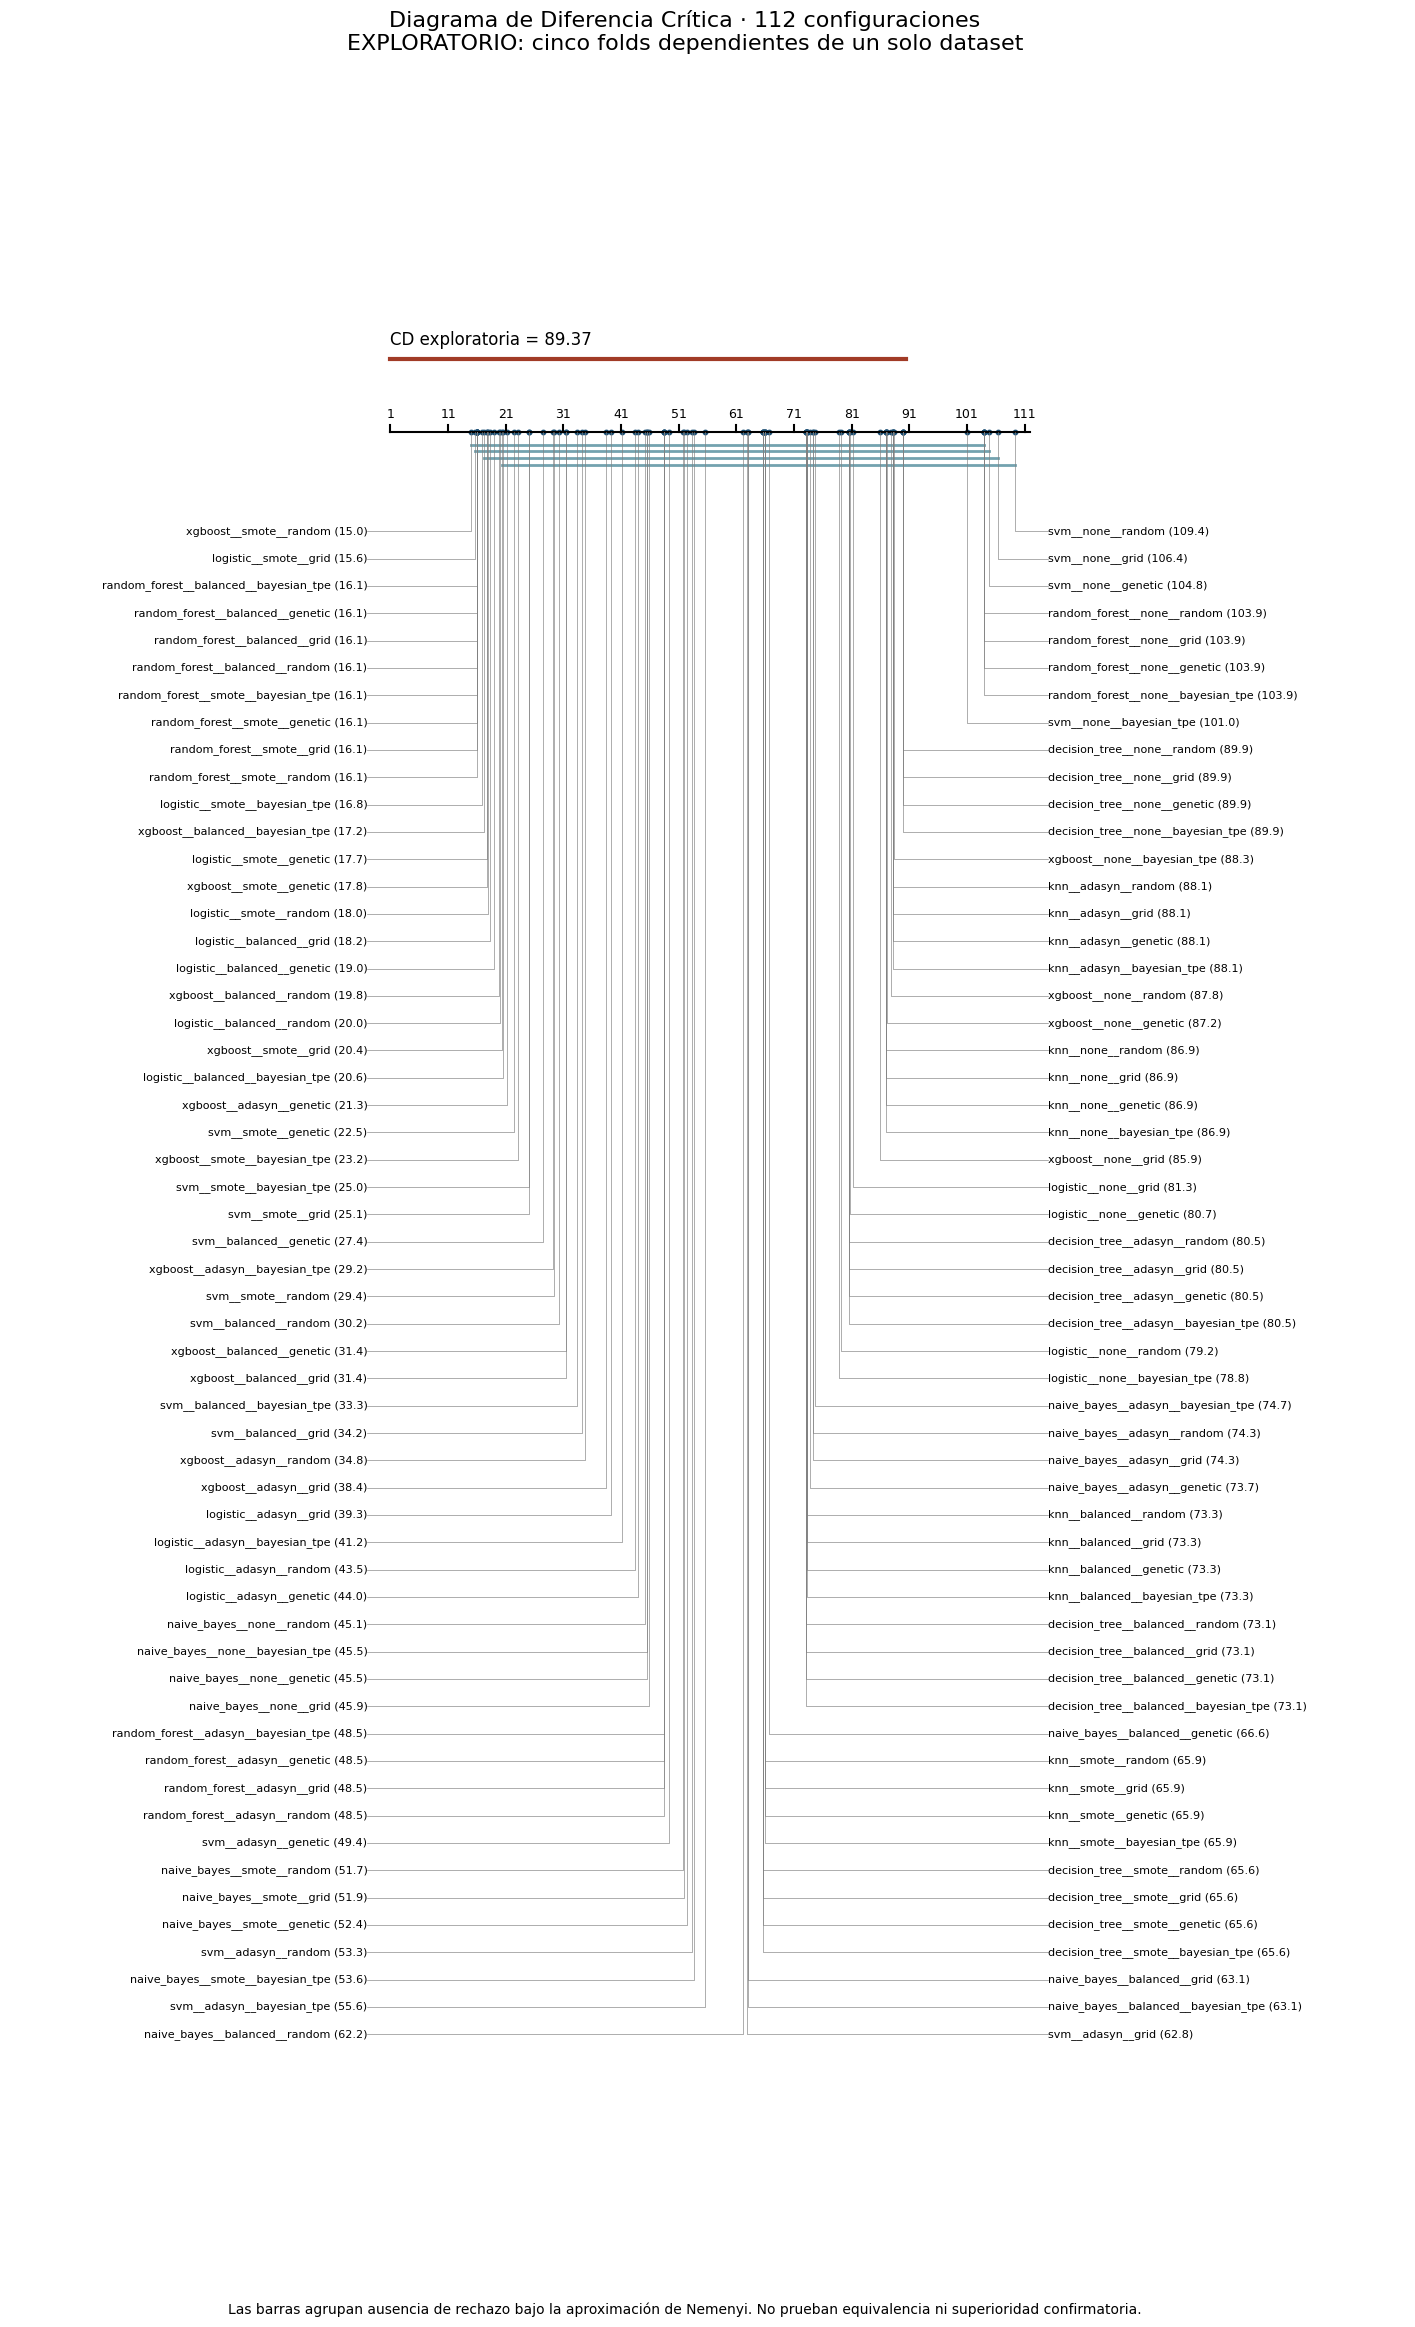

In [ ]:
names=RANGOS_MEDIOS.index.tolist(); ranks=RANGOS_MEDIOS.to_numpy(); cd=CD
# Ventanas maximales de rangos cuyo diámetro no supera CD. Cada par dentro
# de una barra tiene p>=.05; pertenecer a una barra no acredita equivalencia.
groups=[]
for i in range(k):
    j=int(np.searchsorted(ranks,ranks[i]+cd,side='right')-1)
    if j>i and not any(a<=i and b>=j for a,b in groups): groups.append((i,j))
groups=[(a,b) for a,b in groups if not any(c<=a and d>=b and (c,d)!=(a,b) for c,d in groups)]
fig,ax=plt.subplots(figsize=(18,24))
ax.plot([1,k],[0,0],color='black')
for tick in range(1,k+1,10):
    ax.plot([tick,tick],[0,.2],color='black'); ax.text(tick,.4,str(tick),ha='center',fontsize=9)
ax.plot([1,1+cd],[2,2],lw=3,color='#a13b26'); ax.text(1,2.4,f'CD exploratoria = {cd:.2f}',fontsize=12)
for j,(a,b) in enumerate(groups): ax.plot([ranks[a],ranks[b]],[-.35-j*.18]*2,lw=2,color='#387b8d',alpha=.7)
offset=2+len(groups)*.18
half=(k+1)//2
for i,(name,rank) in enumerate(zip(names,ranks)):
    left=i<half; row=i if left else k-1-i; y=-offset-row*.75
    end=-3 if left else k+3
    ax.plot([rank,rank,end],[0,y,y],lw=.45,color='gray')
    ax.scatter([rank],[0],s=10,color='#1c4f74')
    ax.text(end,y,f'{name} ({rank:.1f})',ha='right' if left else 'left',va='center',fontsize=8)
ax.set(xlim=(-65,k+65),ylim=(-offset-half*.75-1,5)); ax.axis('off')
fig.suptitle('Diagrama de Diferencia Crítica · 112 configuraciones\nEXPLORATORIO: cinco folds dependientes de un solo dataset',fontsize=16)
fig.text(.5,.02,'Las barras agrupan ausencia de rechazo bajo la aproximación de Nemenyi. No prueban equivalencia ni superioridad confirmatoria.',ha='center',fontsize=10)
plt.show(); plt.close(fig)

**Interpretación.** La CD es grande respecto del rango posible, por lo que solo separaciones extremas aparecen bajo el umbral nominal. Las mejores configuraciones quedan conectadas con muchas alternativas. Las barras no prueban igualdad y los 31 pares nominales no justifican afirmaciones confirmatorias con folds dependientes. Se conserva el universo completo de 112 configuraciones en el diagrama.

In [ ]:
finalistas=json.loads((ESTADISTICA/'fase6_control.json').read_text(encoding='utf-8'))['finalists']
efectos=[]
for a,b in combinations([r['experiment_id'] for r in finalistas],2):
    delta=MATRIZ[a]-MATRIZ[b]
    efectos.append({'a':a,'b':b,'mean_delta_f1':delta.mean(),'sd_delta_f1':delta.std(ddof=1),
                    'folds_a_higher':int((delta>0).sum()),'folds':5})
tabla(pd.DataFrame(efectos))

a,b,mean_delta_f1,sd_delta_f1,folds_a_higher,folds
random_forest__smote__bayesian_tpe,xgboost__smote__random,0.000431,0.011252,2,5
random_forest__smote__bayesian_tpe,logistic__smote__grid,0.004467,0.015267,3,5
xgboost__smote__random,logistic__smote__grid,0.004037,0.013711,2,5


**Interpretación.** Las diferencias de F1 se calculan emparejando folds de cada par, no tratando sus resultados como dos muestras independientes. La diferencia media RF–SMOTE frente a XGBoost–SMOTE–Random es aproximadamente **0,00043**. Es pequeña y no basta para afirmar relevancia práctica; la DS de diferencias describe dispersión, no un error estándar que pueda calcularse suponiendo independencia. No se utiliza Cliff como si los folds formaran muestras independientes.

#### Modelos finales y procedencia de las comparaciones dirigidas

Se congelaron las tres familias de mayor F1 medio externo, con desempate por identificador, antes de consultar el test histórico: Random Forest–SMOTE–TPE, XGBoost–SMOTE–Random y Logística–SMOTE–Grid. Los cuatro optimizadores de RF–SMOTE empataron; elegir TPE por identificador no implica una ventaja suya.

Para cada configuración se realizó una selección de parámetros con tres folds internos en todo desarrollo y 24 evaluaciones, seguida de un ajuste final. Son **219 ajustes adicionales ya guardados** (3 × [24 × 3 + 1]). No se reutilizó el modelo de un fold externo por haber obtenido el mejor resultado. Los modelos finales quedaron persistidos antes de leer el test para esta comparación. Las celdas presentes solo recuperan sus registros.

In [ ]:
finalistas=json.loads((ESTADISTICA/'fase6_control.json').read_text(encoding='utf-8'))['finalists']
filas=[]
for spec in finalistas:
    registro=json.loads((ANALISIS/'finalistas'/spec['experiment_id']/'complete.json').read_text(encoding='utf-8'))
    filas.append({'Configuración':spec['experiment_id'],'Parámetros finales':json.dumps(registro['params'],ensure_ascii=False),'F1 selección interna final':registro['search']['best_inner_f1']})
tabla(pd.DataFrame(filas))

Configuración,Parámetros finales,F1 selección interna final
random_forest__smote__bayesian_tpe,"{""n_estimators"": 100, ""max_depth"": 8, ""min_samples_leaf"": 5, ""max_features"": ""sqrt""}",0.636521
xgboost__smote__random,"{""n_estimators"": 100, ""max_depth"": 2, ""learning_rate"": 0.06821169686898654, ""subsample"": 0.941978817394868}",0.632496
logistic__smote__grid,"{""C"": 0.5336699231206307, ""penalty"": ""l1""}",0.631012


**Interpretación.** Estos parámetros pertenecen al ajuste final sobre desarrollo completo, no a una selección retrospectiva por el test. Su F1 de selección sigue siendo interno y no reemplaza el resultado externo medio. La búsqueda adicional no modifica ninguno de los resultados oficiales conservados.

In [ ]:
PRED_TEST={spec['experiment_id']:leer_tabla('finalistas/'+spec['experiment_id']+'/test_predictions.csv') for spec in finalistas}
filas=[]
for eid,pred in PRED_TEST.items():
    filas.append({'experiment_id':eid,**metricas_predicciones(pred.y_true,pred.y_pred,pred.score,pred.probability)})
METRICAS_TEST=pd.DataFrame(filas)
tabla(METRICAS_TEST[['experiment_id']+METRICAS])

experiment_id,accuracy,precision_positive,recall_positive,f1_positive,roc_auc,brier,ece
random_forest__smote__bayesian_tpe,0.767921,0.546720,0.735294,0.627138,0.843836,0.153299,0.115525
xgboost__smote__random,0.768630,0.545802,0.764706,0.636971,0.842123,0.153878,0.112707
logistic__smote__grid,0.746629,0.514731,0.794118,0.624606,0.842468,0.166344,0.141529


**Interpretación.** En el test histórico, XGBoost obtuvo F1=0,6370, RF=0,6271 y Logística=0,6246; RF tuvo AUC=0,84384, frente a 0,84212 y 0,84247. El orden de F1 difiere del máximo externo de desarrollo y no se usa para seleccionar otro ganador. Logística detecta más abandonos (Recall≈0,7941), con menor Precision (≈0,5147). El test ya estaba expuesto: estos resultados son suplementarios, no confirmación externa nueva.

#### DeLong dirigido, corrección múltiple e incertidumbre

DeLong se aplicó únicamente a los scores de los **tres modelos fijos sobre los mismos 1.409 clientes** del test histórico. No se aplicó a predicciones OOF de modelos diferentes por fold. Se calcularon componentes U-estadísticos con aportación 0,5 de los empates, covarianza pareada, diferencia de AUC y estadístico normal z. Para esta aproximación no se atribuyen grados de libertad de una t.

Se predefinió la familia de tres pares y se aplicó **Holm** a sus p-valores. El cálculo condicional supone clientes IID; no demuestra ese supuesto ni elimina exposición histórica o selección previa. Su alcance es suplementario y exploratorio.

Los IC ya calculados utilizan **2.000 remuestreos pareados estratificados de clientes**, conservando los mismos índices para todos los modelos. Son IC percentiles marginales del 95 %, condicionales a modelos y prevalencia, no simultáneos ni incertidumbre completa de entrenamiento. La asimetría bootstrap de métricas fue pequeña (|asimetría|<0,18); se mantuvo percentil en lugar de BCa. Las diferencias absolutas de AUC, F1 y Recall constituyen tamaños de efecto directamente interpretables en la escala de las métricas.

In [ ]:
def delong_covariance(y,scores):
    """AUC y covarianza pareada de DeLong mediante componentes U-estadísticos."""
    y=np.asarray(y); scores=np.asarray(scores)
    assert scores.ndim==2 and scores.shape[1]==len(y) and np.isfinite(scores).all()
    m,n=int((y==1).sum()),int((y==0).sum()); assert min(m,n)>1
    v10=[]; v01=[]; auc=[]
    for s in scores:
        positive=s[y==1]; negative=s[y==0]
        concordance=(positive[:,None]>negative).astype(float)+.5*(positive[:,None]==negative)
        v10.append(concordance.mean(axis=1)); v01.append(concordance.mean(axis=0)); auc.append(concordance.mean())
    covariance=np.atleast_2d(np.cov(v10,ddof=1))/m+np.atleast_2d(np.cov(v01,ddof=1))/n
    return np.array(auc),covariance

def holm(pvalues):
    """Ajuste escalonado de Holm para la familia predefinida de tres pares."""
    p=np.asarray(pvalues); order=np.argsort(p); adjusted=np.empty(len(p))
    adjusted[order]=np.minimum(1,np.maximum.accumulate(p[order]*(len(p)-np.arange(len(p)))))
    return adjusted

In [ ]:
names=list(PRED_TEST); y=PRED_TEST[names[0]].y_true.to_numpy()
for pred in PRED_TEST.values(): np.testing.assert_array_equal(pred.y_true,y)
auc,cov=delong_covariance(y,np.vstack([PRED_TEST[name].score for name in names]))
bootstrap=np.load(ESTADISTICA/'bootstrap_test_pareado.npz')
np.testing.assert_array_equal(bootstrap['names'],names)
samples=bootstrap['samples']; rows=[]
for i,j in combinations(range(len(names)),2):
    delta=auc[i]-auc[j]; se=np.sqrt(cov[i,i]+cov[j,j]-2*cov[i,j]); z=delta/se
    row={'a':names[i],'b':names[j],'delta_auc':delta,'z':z,'p_raw':float(2*norm.sf(abs(z)))}
    for q,metric in enumerate(['f1','recall','auc']):
        low,high=np.quantile(samples[:,i,q]-samples[:,j,q],[.025,.975])
        row[metric+'_bootstrap_low']=low; row[metric+'_bootstrap_high']=high
        if metric!='auc':
            field='f1_positive' if metric=='f1' else 'recall_positive'
            metrics=METRICAS_TEST.set_index('experiment_id')
            row['delta_'+metric]=metrics.loc[names[i],field]-metrics.loc[names[j],field]
    rows.append(row)
DELONG=pd.DataFrame(rows); DELONG['p_holm']=holm(DELONG.p_raw)
np.testing.assert_allclose(DELONG[['delta_auc','z','p_raw','p_holm']],leer_tabla('estadistica/delong_holm.csv')[['delta_auc','z','p_raw','p_holm']],atol=1e-12)
tabla(DELONG[['a','b','delta_auc','z','p_raw','p_holm','auc_bootstrap_low','auc_bootstrap_high']])

a,b,delta_auc,z,p_raw,p_holm,auc_bootstrap_low,auc_bootstrap_high
random_forest__smote__bayesian_tpe,xgboost__smote__random,0.001713,0.637623,5.237e-01,1.000e+00,-0.003375,0.006950
random_forest__smote__bayesian_tpe,logistic__smote__grid,0.001368,0.387848,6.981e-01,1.000e+00,-0.005478,0.008272
xgboost__smote__random,logistic__smote__grid,-0.000345,-0.099767,9.205e-01,1.000e+00,-0.007250,0.006560


**Interpretación.** Los tres p ajustados son **1,0** y los IC de diferencia AUC incluyen cero. No se detectan diferencias con este procedimiento; no se prueba equivalencia. Para RF–XGBoost, ΔAUC≈0,00171 e IC bootstrap≈[−0,00337; 0,00695] muestran que el cambio observado es pequeño e incierto. Holm controla la familia dirigida bajo sus supuestos, pero no corrige la exposición histórica del test ni la selección previa entre configuraciones.

In [ ]:
tabla(DELONG[['a','b','delta_f1','f1_bootstrap_low','f1_bootstrap_high','delta_recall','recall_bootstrap_low','recall_bootstrap_high']])

a,b,delta_f1,f1_bootstrap_low,f1_bootstrap_high,delta_recall,recall_bootstrap_low,recall_bootstrap_high
random_forest__smote__bayesian_tpe,xgboost__smote__random,-0.009833,-0.025816,0.005699,-0.029412,-0.053476,-0.005348
random_forest__smote__bayesian_tpe,logistic__smote__grid,0.002532,-0.020274,0.024681,-0.058824,-0.090909,-0.026738
xgboost__smote__random,logistic__smote__grid,0.012365,-0.008470,0.031890,-0.029412,-0.058824,0.000000


**Interpretación.** RF–XGBoost tiene ΔF1≈−0,00983 con IC que incluye cero y ΔRecall≈−0,02941, cuyo IC condicional es negativo. Esto describe un intercambio de detección para modelos fijos; no constituye un contraste simultáneo confirmatorio sobre todas las métricas. Se muestran también efectos desfavorables, sin transformar significancia nominal o ausencia de rechazo en superioridad práctica.

In [ ]:
def remuestreo_pareado(y,scores,labels,draws=2000):
    """Bootstrap estratificado: mismos clientes remuestreados para cada modelo."""
    rng=np.random.default_rng(np.random.SeedSequence([42,107]))
    pos=np.flatnonzero(y==1); neg=np.flatnonzero(y==0)
    samples=np.empty((draws,len(scores),3))
    for b in range(draws):
        ix=np.r_[rng.choice(pos,len(pos),replace=True),rng.choice(neg,len(neg),replace=True)]
        truth=y[ix]
        for j in range(len(scores)):
            lab=labels[j,ix]; tp=np.sum((lab==1)&(truth==1)); fp=np.sum((lab==1)&(truth==0))
            samples[b,j]=[2*tp/(len(pos)+tp+fp),tp/len(pos),roc_auc_score(truth,scores[j,ix])]
    return samples
# Se reutiliza samples del NPZ: no se vuelve a llamar a remuestreo_pareado.

In [ ]:
intervalos=[]
for j,name in enumerate(names):
    for q,metric in enumerate(['f1','recall','auc']):
        low,high=np.quantile(samples[:,j,q],[.025,.975])
        intervalos.append({'experiment_id':name,'metric':metric,'low':low,'high':high,
                          'bootstrap_skewness':float(skew(samples[:,j,q])),'draws':len(samples)})
tabla(pd.DataFrame(intervalos))

experiment_id,metric,low,high,bootstrap_skewness,draws
random_forest__smote__bayesian_tpe,f1,0.596132,0.659794,0.020285,2000
random_forest__smote__bayesian_tpe,recall,0.692513,0.780749,0.023220,2000
random_forest__smote__bayesian_tpe,auc,0.821366,0.864374,-0.171813,2000
xgboost__smote__random,f1,0.605926,0.666667,-0.028509,2000
xgboost__smote__random,recall,0.724532,0.807487,0.013727,2000
xgboost__smote__random,auc,0.819737,0.861942,-0.178372,2000
logistic__smote__grid,f1,0.596734,0.653061,-0.013002,2000
logistic__smote__grid,recall,0.754011,0.831618,-0.086364,2000
logistic__smote__grid,auc,0.820224,0.862264,-0.155201,2000


**Interpretación.** Los intervalos cuantifican variación por remuestrear clientes del test manteniendo fijos los modelos. Sus anchuras recuerdan la incertidumbre que no muestran los valores puntuales; no incorporan variabilidad de selección o reentrenamiento. La asimetría observada respalda usar percentiles para este estimando, sin afirmar cobertura incondicional de todo el procedimiento experimental.

### 3.2 Interpretabilidad global y local: SHAP y LIME

Se explican el candidato RF–SMOTE y XGBoost–SMOTE–Random. La selección procede del ranking externo exploratorio y de la comparación dirigida; no se afirma que exista un ganador confirmado ni se ejecutan explicaciones sobre las 112 configuraciones.

**SHAP.** TreeSHAP interventional explica la probabilidad nativa positiva del modelo final. El fondo contiene 100 clientes reales de desarrollo elegidos con semilla 42; el análisis global incluye los 5.634 clientes de desarrollo. Se explica el modelo sobre datos reales, no sobre clientes sintéticos. Se verificó que referencia más suma de contribuciones reproduce la probabilidad con tolerancia 10⁻⁵. Las columnas one-hot se agregaron por variable para resumir importancia; su suma no equivale a recalcular Shapley para otro juego de variables agrupadas.

En RF se detectó un problema numérico de redondeo en la ruta interventional de SHAP 0.48.0. La copia de umbrales del explicador se representó mediante el mayor float32 menor o igual al umbral original; para entradas float32 conserva exactamente la comparación de scikit-learn. Se comprobó igualdad de probabilidades en desarrollo y test. No se modificó el modelo ni se corrigieron contribuciones a posteriori. Los bloques diagnósticos fallidos se conservaron separados de las explicaciones válidas.

**Selección local.** Para cada modelo se seleccionaron un acierto y un error del test con máxima confianza, con desempate por índice. Esta regla predefinida permite inspeccionar también errores seguros; los cuatro casos no representan la distribución completa de errores.

**LIME.** En las mismas observaciones y para la misma probabilidad nativa, se ajustó un sustituto local con 5.000 perturbaciones, diez variables explicativas y semillas 42, 43 y 44. Se reconstruyen las categorías originales antes de pasar perturbaciones por el Pipeline. Se guardan R² local ponderado, probabilidad aproximada y estabilidad de las cinco variables principales mediante Jaccard.

SHAP usa variables transformadas, incluida AvgChargePerMonth; LIME usa variables originales. Sus coeficientes no son numéricamente intercambiables. Ambos pueden romper dependencias entre servicios e importes durante perturbaciones; las atribuciones describen el modelo y no identifican causas del abandono. Se explica la salida nativa, **no la rama sigmoid**.

#### Random Forest: explicación global y casos locales

Las contribuciones se expresan en unidades de probabilidad respecto del fondo. El color del resumen representa el valor de la columna transformada; no cambia el signo de la contribución.

In [ ]:
import cloudpickle
import shap

def datos_explicacion(eid):
    """Transforma datos con el Pipeline ya ajustado; no llama fit."""
    folder=ANALISIS/'finalistas'/eid
    registro=json.loads((folder/'complete.json').read_text(encoding='utf-8'))
    assert hashlib.sha256((folder/'pipeline.pkl').read_bytes()).hexdigest()==registro['pipeline_hash']
    with (folder/'pipeline.pkl').open('rb') as file: pipeline=cloudpickle.load(file)
    saved=np.load(ANALISIS/'interpretabilidad'/eid/'shap_global.npz')
    raw=pd.read_csv(ROOT/'WA_Fn-UseC_-Telco-Customer-Churn.csv').loc[saved['row_ids']].drop(columns=['customerID','Churn'])
    z=pipeline.named_steps['prep'].transform(pipeline.named_steps['features'].transform(raw))
    return pipeline,raw,np.asarray(z),saved

def calcular_shap(pipeline,z,background_positions):
    """Procedimiento original; solo necesario si no se conservaran las atribuciones."""
    estimator=pipeline.named_steps['classifier'].estimator_
    if estimator.__class__.__name__=='RandomForestClassifier':
        z=z.astype(np.float32)
    explainer=shap.TreeExplainer(estimator,data=z[background_positions],
                               feature_perturbation='interventional',model_output='probability')
    if estimator.__class__.__name__=='RandomForestClassifier':
        t=explainer.model.thresholds; rounded=t.astype(np.float32)
        explainer.model.thresholds=np.where(rounded.astype(float)>t,np.nextafter(rounded,np.float32(-np.inf)),rounded).astype(float)
    values=np.asarray(explainer.shap_values(z,check_additivity=False))
    if values.ndim==3: values=values[:,:,1]
    return values,float(np.asarray(explainer.expected_value).reshape(-1)[-1])

def grafico_shap_global(eid):
    """Dibuja el resumen a partir de atribuciones y valores transformados reales."""
    pipeline,raw,z,saved=datos_explicacion(eid)
    values,base=saved['values'],float(saved['base'])
    assert values.shape==z.shape
    np.testing.assert_allclose(base+values.sum(axis=1),pipeline.predict_proba(raw)[:,1],atol=1e-5)
    shap.summary_plot(values,z,feature_names=saved['feature_names'],max_display=20,show=False,rng=np.random.default_rng(42))
    plt.title('SHAP global: probabilidad nativa de abandono')
    plt.tight_layout(); plt.show(); plt.close('all')

def grafico_shap_local(eid,row_id):
    """Genera waterfall desde contribuciones locales guardadas."""
    folder=ANALISIS/'interpretabilidad'/eid
    data=pd.read_csv(folder/f'shap_local_{row_id}.csv',float_precision='round_trip')
    base=float(np.load(folder/'shap_global.npz')['base'])
    shap.plots.waterfall(shap.Explanation(values=data.shap.to_numpy(),base_values=base,
                        data=data.value.to_numpy(),feature_names=data.feature.to_numpy()),max_display=12,show=False)
    plt.tight_layout(); plt.show(); plt.close('all')

def calcular_lime(pipeline,raw,observation,seed=42):
    """Procedimiento original de LIME; las explicaciones de la entrega ya existen."""
    from lime.lime_tabular import LimeTabularExplainer
    train=raw.copy(); obs=observation.copy()
    train['TotalCharges']=pd.to_numeric(train.TotalCharges,errors='coerce').fillna(0)
    obs['TotalCharges']=pd.to_numeric(obs.TotalCharges,errors='coerce').fillna(0)
    columns=list(train.columns); categories={}
    for i,c in enumerate(columns):
        if train[c].dtype=='object':
            labels=sorted(train[c].unique()); categories[i]=labels; mapping={v:j for j,v in enumerate(labels)}
            train[c]=train[c].map(mapping); obs[c]=obs[c].map(mapping)
    def predict(array):
        frame=pd.DataFrame(array,columns=columns)
        for i,labels in categories.items():
            indices=np.clip(np.rint(array[:,i]).astype(int),0,len(labels)-1)
            frame[columns[i]]=[labels[j] for j in indices]
        return pipeline.predict_proba(frame)
    explainer=LimeTabularExplainer(train.to_numpy(dtype=float),feature_names=columns,
        categorical_features=list(categories),categorical_names=categories,class_names=['permanece','abandono'],
        mode='classification',random_state=seed,discretize_continuous=True)
    return explainer.explain_instance(obs.iloc[0].to_numpy(dtype=float),predict,labels=(1,),num_features=10,num_samples=5000)

def grafico_lime(eid,row_id):
    """Traza los pesos del sustituto guardado, sin generar perturbaciones nuevas."""
    records=json.loads((ANALISIS/'interpretabilidad'/eid/'lime_resultados.json').read_text(encoding='utf-8'))
    exp=next(r for r in records if r['row_id']==row_id and r['seed']==42)
    labels,weights=zip(*reversed(exp['weights']))
    fig,ax=plt.subplots(figsize=(9,5))
    ax.barh(range(len(weights)),weights,color=['green' if w>0 else 'red' for w in weights])
    ax.set(yticks=range(len(labels)),yticklabels=labels,xlabel='Peso del sustituto local',title='LIME: clase abandono')
    fig.tight_layout(); plt.show(); plt.close(fig)

c:\Users\natal\Downloads\anaconda\envs\ml_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


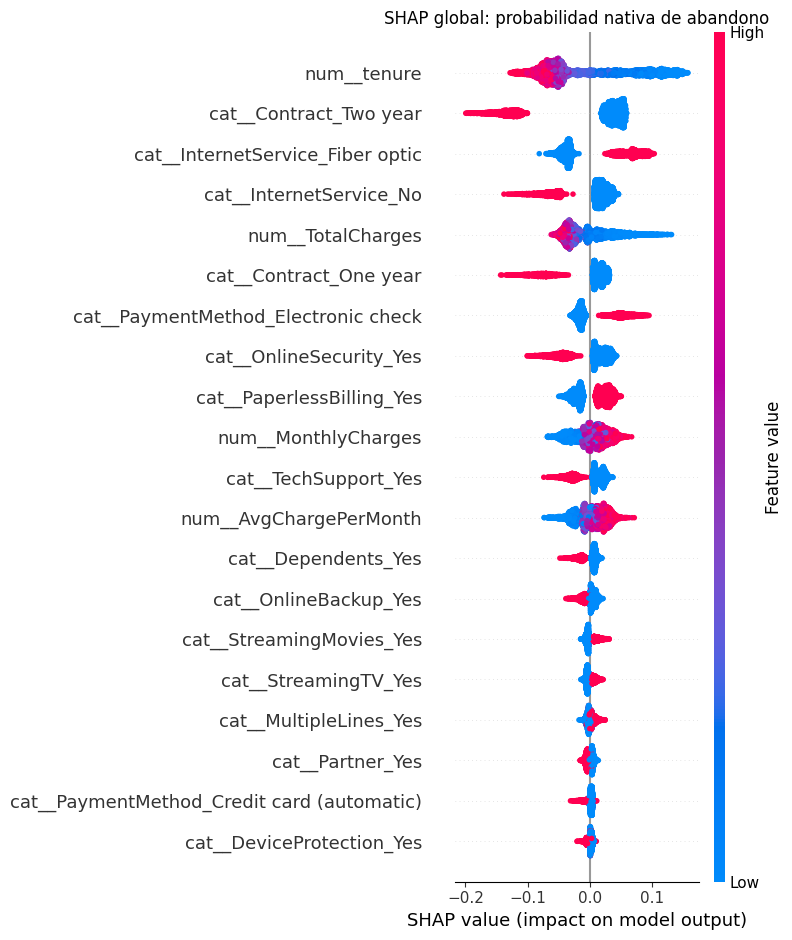

In [ ]:
grafico_shap_global('random_forest__smote__bayesian_tpe')

**Interpretación.** Las mayores importancias medias absolutas agrupadas corresponden a Contract (0.0771), InternetService (0.0694), tenure (0.0675). El resumen muestra variación y signo por cliente; una importancia absoluta alta no determina por sí sola dirección causal. El error máximo de aditividad fue 1.36e-08, inferior a 10⁻⁵ en las 5.634 observaciones. Estas explicaciones caracterizan el modelo final ajustado, no una medida de generalización adicional.

**Caso 4267: acierto de alta confianza.** Clase observada=0; probabilidad nativa de abandono=0.0081. El identificador permite rastrear la observación sin volver a escoger un ejemplo.

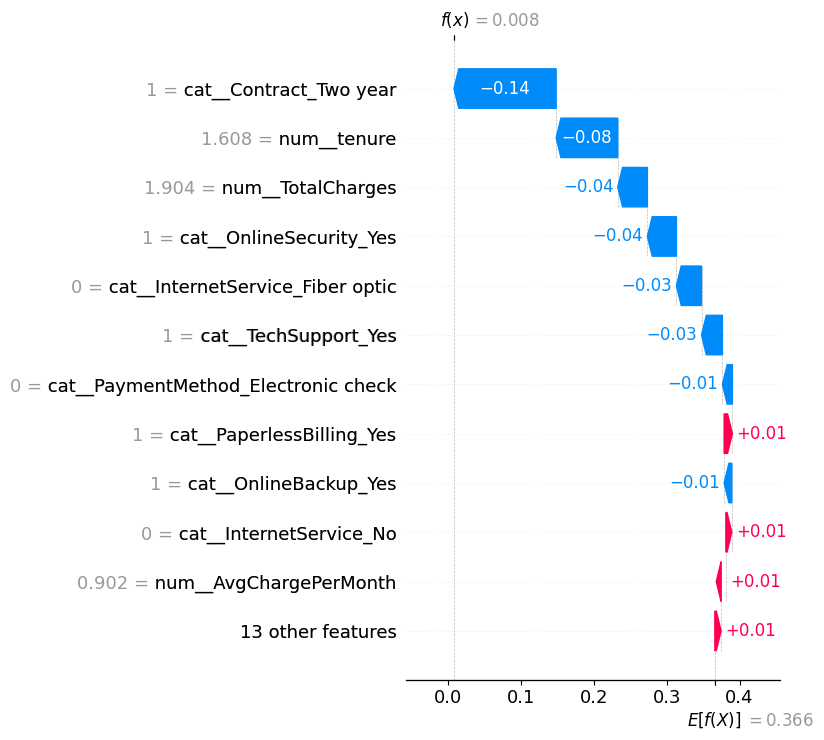

In [ ]:
grafico_shap_local('random_forest__smote__bayesian_tpe', 4267)

**Interpretación SHAP.** Las dos contribuciones negativas de mayor magnitud son cat__Contract_Two year (-0.1402), num__tenure (-0.0845); reducen la probabilidad respecto del fondo. La etiqueta predicha de permanencia coincide con lo observado. El caso ilustra una decisión correcta, sin implicar que esas variables garanticen permanencia.

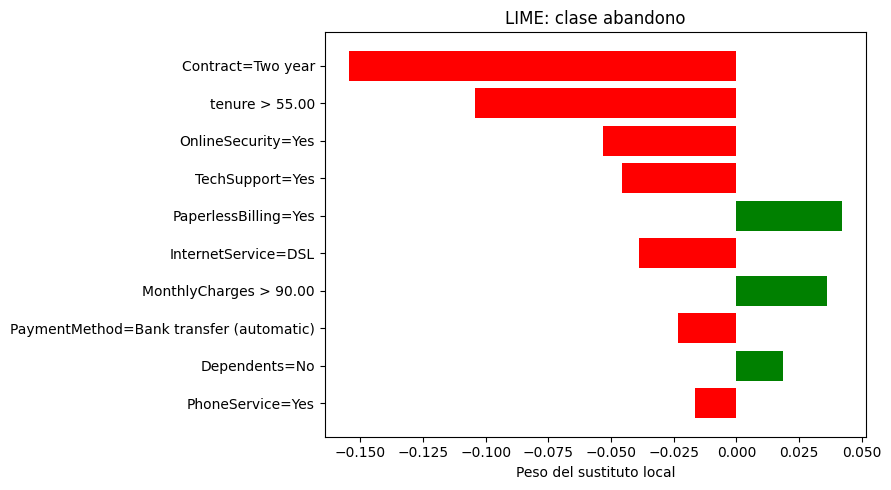

In [ ]:
grafico_lime('random_forest__smote__bayesian_tpe', 4267)

**Interpretación LIME.** La figura corresponde a semilla 42; el sustituto local aproxima 0.0867 frente a la probabilidad real 0.0081, con R² ponderado=0.3992. Entre tres semillas, R² varió de 0.3992 a 0.4090; el Jaccard medio del top 5 fue 0.778 y el error absoluto local máximo 0.0920. La estabilidad de variables no garantiza fidelidad de probabilidad. LIME describe una aproximación local, mientras SHAP conserva aditividad; no se exige que sus pesos coincidan.

**Caso 4386: error de alta confianza.** Clase observada=1; probabilidad nativa de abandono=0.0153. El identificador permite rastrear la observación sin volver a escoger un ejemplo.

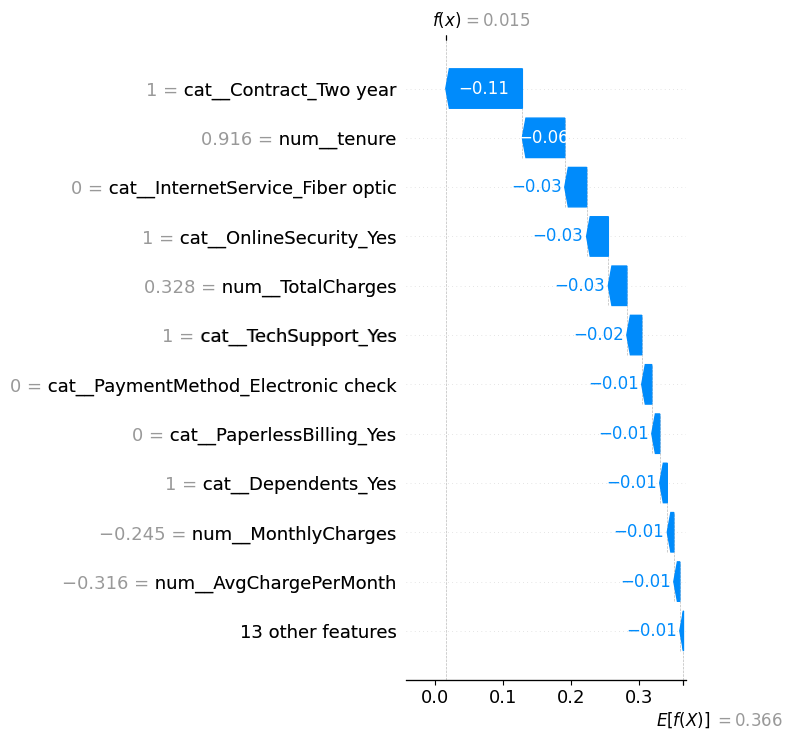

In [ ]:
grafico_shap_local('random_forest__smote__bayesian_tpe', 4386)

**Interpretación SHAP.** Las dos contribuciones negativas de mayor magnitud son cat__Contract_Two year (-0.1130), num__tenure (-0.0626); reducen la probabilidad respecto del fondo. El cliente abandonó pese a recibir una probabilidad baja: es un falso negativo relevante para retención. Las atribuciones explican cómo se produjo la decisión equivocada; no justifican su corrección ni revelan por qué abandonó el cliente.

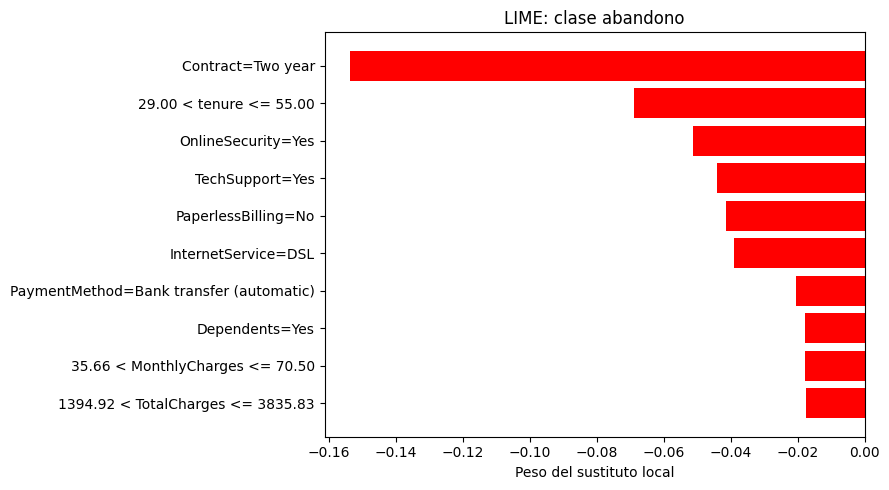

In [ ]:
grafico_lime('random_forest__smote__bayesian_tpe', 4386)

**Interpretación LIME.** La figura corresponde a semilla 42; el sustituto local aproxima 0.0058 frente a la probabilidad real 0.0153, con R² ponderado=0.3384. Entre tres semillas, R² varió de 0.3329 a 0.3384; el Jaccard medio del top 5 fue 0.778 y el error absoluto local máximo 0.0140. La estabilidad de variables no garantiza fidelidad de probabilidad. LIME describe una aproximación local, mientras SHAP conserva aditividad; no se exige que sus pesos coincidan.

#### XGBoost: explicación global y casos locales

Las contribuciones se expresan en unidades de probabilidad respecto del fondo. El color del resumen representa el valor de la columna transformada; no cambia el signo de la contribución.

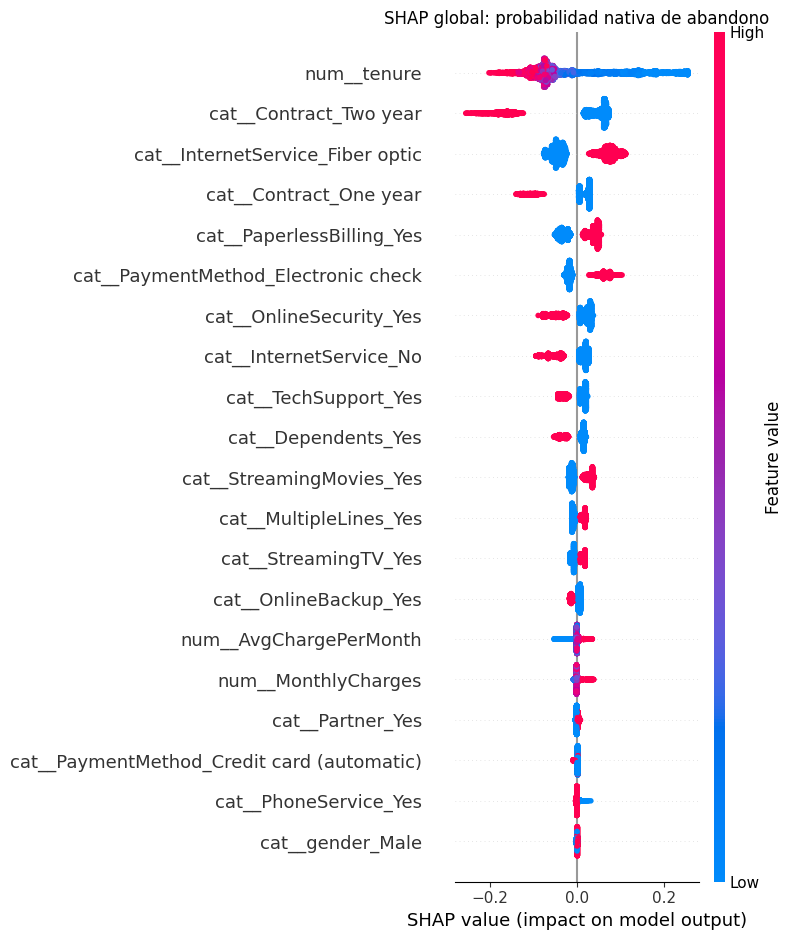

In [ ]:
grafico_shap_global('xgboost__smote__random')

**Interpretación.** Las mayores importancias medias absolutas agrupadas corresponden a Contract (0.1051), tenure (0.0927), InternetService (0.0733). El resumen muestra variación y signo por cliente; una importancia absoluta alta no determina por sí sola dirección causal. El error máximo de aditividad fue 1.75e-07, inferior a 10⁻⁵ en las 5.634 observaciones. Estas explicaciones caracterizan el modelo final ajustado, no una medida de generalización adicional.

**Caso 2221: acierto de alta confianza.** Clase observada=0; probabilidad nativa de abandono=0.0116. El identificador permite rastrear la observación sin volver a escoger un ejemplo.

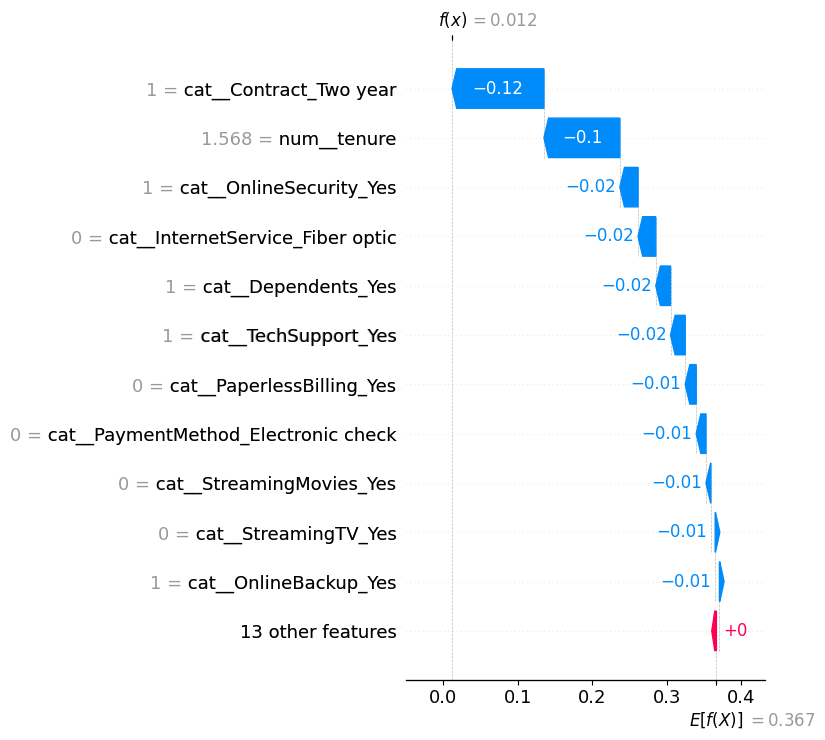

In [ ]:
grafico_shap_local('xgboost__smote__random', 2221)

**Interpretación SHAP.** Las dos contribuciones negativas de mayor magnitud son cat__Contract_Two year (-0.1234), num__tenure (-0.1019); reducen la probabilidad respecto del fondo. La etiqueta predicha de permanencia coincide con lo observado. El caso ilustra una decisión correcta, sin implicar que esas variables garanticen permanencia.

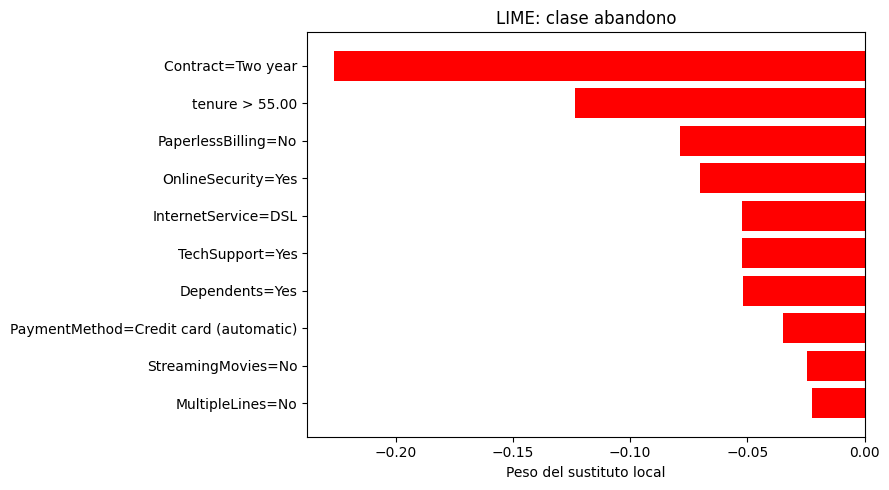

In [ ]:
grafico_lime('xgboost__smote__random', 2221)

**Interpretación LIME.** La figura corresponde a semilla 42; el sustituto local aproxima -0.1815 frente a la probabilidad real 0.0116, con R² ponderado=0.4424. Entre tres semillas, R² varió de 0.4406 a 0.4474; el Jaccard medio del top 5 fue 1.000 y el error absoluto local máximo 0.2180. La estabilidad de variables no garantiza fidelidad de probabilidad. LIME describe una aproximación local, mientras SHAP conserva aditividad; no se exige que sus pesos coincidan.

**Caso 4513: error de alta confianza.** Clase observada=1; probabilidad nativa de abandono=0.0179. El identificador permite rastrear la observación sin volver a escoger un ejemplo.

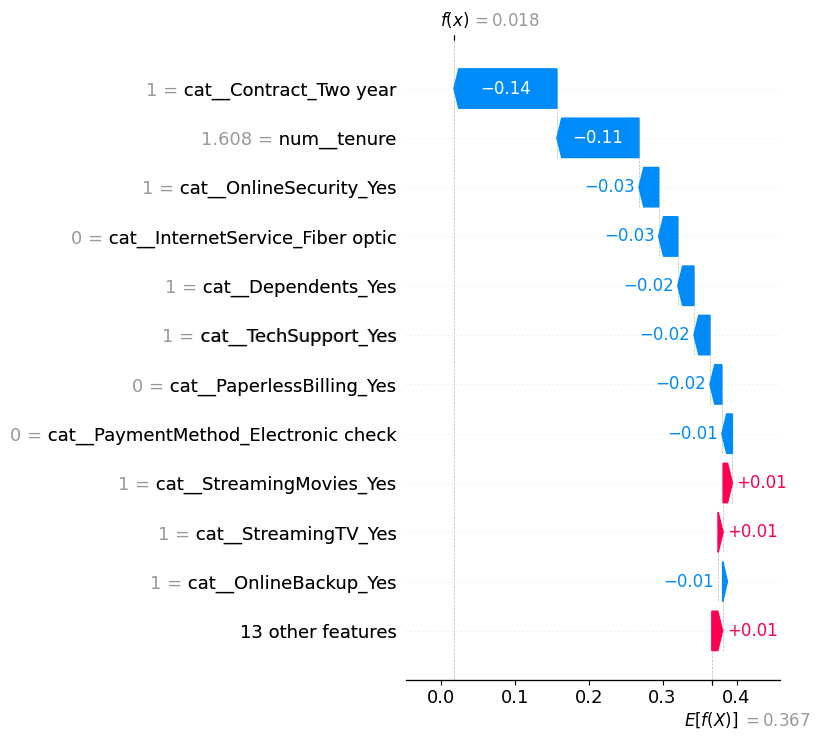

In [ ]:
grafico_shap_local('xgboost__smote__random', 4513)

**Interpretación SHAP.** Las dos contribuciones negativas de mayor magnitud son cat__Contract_Two year (-0.1392), num__tenure (-0.1109); reducen la probabilidad respecto del fondo. El cliente abandonó pese a recibir una probabilidad baja: es un falso negativo relevante para retención. Las atribuciones explican cómo se produjo la decisión equivocada; no justifican su corrección ni revelan por qué abandonó el cliente.

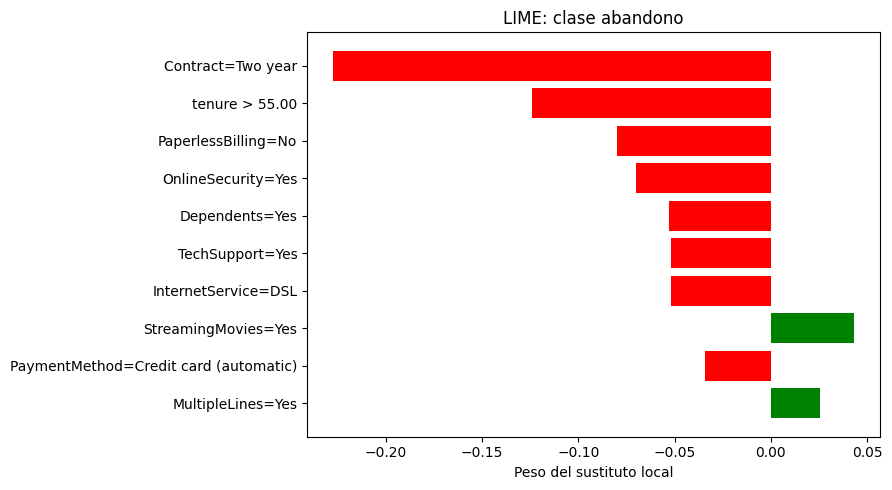

In [ ]:
grafico_lime('xgboost__smote__random', 4513)

**Interpretación LIME.** La figura corresponde a semilla 42; el sustituto local aproxima -0.1141 frente a la probabilidad real 0.0179, con R² ponderado=0.4509. Entre tres semillas, R² varió de 0.4509 a 0.4577; el Jaccard medio del top 5 fue 0.778 y el error absoluto local máximo 0.1456. La estabilidad de variables no garantiza fidelidad de probabilidad. LIME describe una aproximación local, mientras SHAP conserva aditividad; no se exige que sus pesos coincidan.

### 3.3 Conclusiones sustentadas por los resultados

**Resultado observado.** Se completaron 112 configuraciones y 1.680 unidades externas. RF–SMOTE obtuvo F1=0,6384 ± 0,0227, Recall=0,7351, Precision=0,5646, Accuracy=0,7788 y AUC=0,8438 en la realización principal. XGBoost–SMOTE–Random alcanzó F1=0,6380. Los cuatro optimizadores de RF–SMOTE empataron.

**Interpretación.** La diferencia media de F1 RF–XGBoost es aproximadamente 0,00043, pequeña y sujeta a selección entre muchas configuraciones. El Recall se acompañó de falsas alertas; no hay costes cuantificados para traducirlo en beneficio económico. El ranking se conserva como descripción y selección exploratoria, no como confirmación.

**Conclusión sobre optimizadores.** TPE, Genético y Random mejoraron el objetivo interno temprano respecto del orden de Grid, pero no mostraron ventaja universal a 24 evaluaciones ni aceleración temporal universal. Agotar el mismo dominio finito explica algunos empates. La mejora administrativa del registro resolvió trabajo redundante sin reducir el universo ni modificar el aprendizaje.

**Conclusión sobre calibración y explicación.** Sigmoid redujo conjuntamente Brier y ECE en 80 de las 96 configuraciones con probabilidad nativa; no mejoró todas. SHAP identificó patrones relevantes para los modelos y permitió explicar falsos negativos seguros. LIME presentó diferencias de fidelidad entre casos; estabilidad de variables no basta para confiar en su aproximación probabilística. Ninguna explicación identifica efectos causales.

**Alcance estadístico.** Friedman/Nemenyi/CD permanecen exploratorios porque los folds no son bloques independientes. DeLong dirigido no detectó diferencias de AUC después de Holm; esto no prueba equivalencia. Los IC son condicionales a modelos y no incluyen selección o reentrenamiento. El test histórico estaba expuesto y es evidencia suplementaria.

RF–SMOTE se conserva como candidato operativo exploratorio. Una aplicación comercial requiere evaluación prospectiva independiente, costes de intervención explícitos y estabilidad temporal. Estas son necesidades futuras, no experimentos realizados ni motivos para reinterpretar los resultados existentes.